# **1. Setup & Libraries**

In [1]:
!pip install matplotlib-scalebar
!pip install contextily

# For post-hoc seasonal tests
!pip install scikit-posthocs

!pip install pymannkendall


In [2]:
import os
import glob
import calendar

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.ticker import ScalarFormatter
from matplotlib_scalebar.scalebar import ScaleBar
import seaborn as sns
import geopandas as gpd

from scipy.stats import mannwhitneyu, kruskal, wilcoxon
import pymannkendall as mk
import scikit_posthocs as sp


# **2. Load Dataset**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
file_path = '/content/drive/MyDrive/Rainfall/Data/Final processed 3-hourly rainfall data.csv'
df_rain = pd.read_csv(file_path)
df_rain

,StationID,StationName,Latitude,Longitude,Primary_Region,Secondary_Region,Datetime,Year,Month,Day,Time,Season,DewPointTemperature,StationLevelPressure,SP,DR,Humidity,Rainfall
0,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 00:00:00,2003,1,1,0,Winter,12.0,1009.7,0.0,0.0,91.0,0.0
1,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 03:00:00,2003,1,1,3,Winter,13.0,1011.3,0.0,0.0,74.0,0.0
2,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 06:00:00,2003,1,1,6,Winter,15.0,1011.2,4.0,31.0,57.0,0.0
3,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 09:00:00,2003,1,1,9,Winter,9.0,1010.3,2.0,5.0,35.0,0.0
4,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 12:00:00,2003,1,1,12,Winter,13.0,1010.4,0.0,0.0,61.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116614,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 09:00:00,2023,7,31,9,Monsoon,26.0,1016.0,1.0,10.0,73.0,0.0
2116615,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 12:00:00,2023,7,31,12,Monsoon,26.0,1016.0,0.0,0.0,82.0,0.0
2116616,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 15:00:00,2023,7,31,15,Monsoon,26.0,1016.0,0.0,0.0,88.0,0.0
2116617,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 18:00:00,2023,7,31,18,Monsoon,26.0,1016.0,0.0,0.0,88.0,0.0


In [5]:
# REMOVE THE LATE STATION (Example ID: 10325)
# Replace 10325 with the actual ID of the 2008 station
stations_to_drop = [11921]
df_rain = df_rain[~df_rain["StationID"].isin(stations_to_drop)].reset_index(drop=True)
df_rain


,StationID,StationName,Latitude,Longitude,Primary_Region,Secondary_Region,Datetime,Year,Month,Day,Time,Season,DewPointTemperature,StationLevelPressure,SP,DR,Humidity,Rainfall
0,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 00:00:00,2003,1,1,0,Winter,12.0,1009.7,0.0,0.0,91.0,0.0
1,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 03:00:00,2003,1,1,3,Winter,13.0,1011.3,0.0,0.0,74.0,0.0
2,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 06:00:00,2003,1,1,6,Winter,15.0,1011.2,4.0,31.0,57.0,0.0
3,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 09:00:00,2003,1,1,9,Winter,9.0,1010.3,2.0,5.0,35.0,0.0
4,41977,Ambagan(Ctg.),22.3500,91.8167,South East,Coastal,2003-01-01 12:00:00,2003,1,1,12,Winter,13.0,1010.4,0.0,0.0,61.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2069862,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 09:00:00,2023,7,31,9,Monsoon,26.0,1016.0,1.0,10.0,73.0,0.0
2069863,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 12:00:00,2023,7,31,12,Monsoon,26.0,1016.0,0.0,0.0,82.0,0.0
2069864,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 15:00:00,2023,7,31,15,Monsoon,26.0,1016.0,0.0,0.0,88.0,0.0
2069865,11929,Teknaf,20.8667,92.3000,South East,Coastal,2023-07-31 18:00:00,2023,7,31,18,Monsoon,26.0,1016.0,0.0,0.0,88.0,0.0


# **Hyperparameter Training**

In [ ]:
# ============================================================
# QUANTILE LSTM BASELINE + HYPERPARAMETER TUNING (STANDALONE)
# - Temporal-only LSTM (no graph, no regime embedding)
# - Quantile regression with pinball loss + CRPS (log & mm)
# - Risk heads for flash/peak24/acc24 with Brier scores
# - Resume-safe trial tuning with composite objective:
#       0.5 * normalized CRPS_log + 0.5 * normalized mean Brier
#
# Copy into a fresh Colab notebook and run.
# You only need to define df_rain before calling tune().
# ============================================================

import os, json, math, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import average_precision_score, roc_auc_score  # not used now, but harmless

# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42, deterministic=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ----------------------------
# Drive mount (optional, Colab)
# ----------------------------
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass

SAVE_DIR = "/content/drive/MyDrive/Rainfall/Baselines/QuantileLSTM_Tuning/v1"
os.makedirs(SAVE_DIR, exist_ok=True)
print("Saving to:", SAVE_DIR)

# ============================================================
# 1) Utilities
# ============================================================

class NaNIgnoringStandardScaler:
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None
    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_  = np.nanstd(X, axis=0)
        self.std_  = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self
    def transform(self, X):
        return (X - self.mean_) / self.std_

def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()

def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    # Approx CRPS via mean pinball
    losses = []
    for k, q in enumerate(quantiles):
        losses.append(pinball_loss(y_hat[..., k], y_true, q, mask=mask))
    return 2.0 * torch.stack(losses).mean()

def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()

def compute_pos_weight(labels, masks):
    pos = (labels * masks).sum().item()
    tot = masks.sum().item()
    neg = tot - pos
    if pos < 1:
        return 1.0
    w = (neg + 1e-6) / (pos + 1e-6)
    return float(np.clip(w, 1.0, 30.0))

def masked_bce_with_logits(logits, targets, mask, pos_weight):
    loss = F.binary_cross_entropy_with_logits(
        logits, targets, reduction="none", pos_weight=pos_weight
    )
    loss = loss * mask
    return loss.sum() / mask.sum().clamp_min(1.0)

# ============================================================
# 2) Preprocessing: FULL GRID, missingness-aware
# ============================================================

def prepare_full_grid(df_rain):
    df = df_rain.copy()
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    # DR degrees -> sin/cos (NaN-safe)
    dr = df["DR"].astype(np.float32).to_numpy()
    dr_rad = np.deg2rad(dr)
    df["DR_sin"] = np.sin(dr_rad)
    df["DR_cos"] = np.cos(dr_rad)

    # Station table
    stations = (
        df[["StationID", "StationName", "Latitude", "Longitude"]]
        .drop_duplicates()
        .sort_values("StationID")
        .reset_index(drop=True)
    )
    stations["node_index"] = np.arange(len(stations))
    N = len(stations)
    print("Stations:", N)

    # Unique times (3-hourly grid)
    times = np.sort(df["Datetime"].unique())
    T = len(times)
    print("Times:", T)

    # Full cartesian grid: time × station
    full_index = pd.MultiIndex.from_product(
        [times, stations["StationID"].values],
        names=["Datetime", "StationID"],
    )

    meteo_cols = [
        "DewPointTemperature",
        "StationLevelPressure",
        "SP",
        "Humidity",
        "Rainfall",
        "DR_sin",
        "DR_cos",
    ]
    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    df_full = df2.reindex(full_index)
    X_raw = df_full.values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    # Missingness mask (inputs)
    M_in = (~np.isnan(X_raw)).astype(np.float32)

    # Rainfall target + its mask
    rain_idx = meteo_cols.index("Rainfall")
    Y_rain = X_raw[..., rain_idx]
    M_y   = M_in[..., rain_idx]

    # Time features: hour + month (cyclical)
    dt_index = pd.DatetimeIndex(times)
    hour  = dt_index.hour.astype(np.float32)
    month = dt_index.month.astype(np.float32)

    hour_sin = np.sin(2*np.pi*(hour/24.0))
    hour_cos = np.cos(2*np.pi*(hour/24.0))
    month_sin = np.sin(2*np.pi*((month-1)/12.0))
    month_cos = np.cos(2*np.pi*((month-1)/12.0))

    time_feats = np.stack(
        [hour_sin, hour_cos, month_sin, month_cos],
        axis=-1
    ).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    return dict(
        stations=stations,
        times=times,
        X_raw=X_raw,
        M_in=M_in,
        Y_rain=Y_rain,
        M_y=M_y,
        meteo_cols=meteo_cols,
        time_feats=time_feats,
    )

def make_splits(T, train_frac=0.7, val_frac=0.15):
    train_end = int(T * train_frac)
    val_end   = int(T * (train_frac + val_frac))
    return train_end, val_end

def scale_inputs_train_only(X_raw, train_end):
    T, N, F = X_raw.shape
    X_flat = X_raw.reshape(T * N, F)
    train_flat = X_flat[:train_end * N]
    scaler = NaNIgnoringStandardScaler().fit(train_flat)
    X_scaled = scaler.transform(X_flat).reshape(T, N, F).astype(np.float32)
    return X_scaled, scaler

def compute_thresholds_train(Y, M, train_end, q=0.95):
    Y_train = Y[:train_end]
    M_train = M[:train_end]
    N = Y.shape[1]
    thr = np.zeros(N, dtype=np.float32)

    global_vals = Y_train[M_train > 0.5]
    global_fallback = np.nanpercentile(global_vals, q * 100) if global_vals.size > 0 else 0.0

    for j in range(N):
        vals = Y_train[:, j][M_train[:, j] > 0.5]
        if len(vals) < 100:
            thr[j] = global_fallback
        else:
            thr[j] = np.nanpercentile(vals, q * 100)
    return thr

def compute_acc24(Y_rain, M_y, H_out=8):
    """
    Acc24[t,n] = sum_{k=1..H_out} Rain[t+k,n]
    MaskAcc24[t,n] = 1 if all H_out future steps observed
    """
    T, N = Y_rain.shape
    Acc = np.full((T, N), np.nan, dtype=np.float32)
    Mask = np.zeros((T, N), dtype=np.float32)
    for t in range(T - H_out):
        window = Y_rain[t+1:t+1+H_out]
        wmask  = M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok]  = window[:, ok].sum(axis=0)
    return Acc, Mask

# ============================================================
# 3) Dataset (temporal-only)
# ============================================================

class RainDataset(Dataset):
    """
    Each sample anchored at time t:
      Inputs:  t-T_in+1 .. t       (T_in steps)
      Targets: t+1 .. t+H_out      (H_out steps)

    Risk labels (per station):
      flash:   Rain[t+1] >= thr3h
      peak24:  max(Rain[t+1..t+H_out]) >= thr3h, valid if >= peak_min_obs observed
      acc24:   sum(Rain[t+1..t+H_out]) >= thrAcc24, valid if all H_out observed
    """
    def __init__(
        self,
        X_scaled, M_in, time_feats,
        Y_rain, M_y,
        Acc24, MaskAcc24,
        thr3h, thrAcc24,
        t_start, t_end,
        T_in=16, H_out=8,
        peak_min_obs=None,
    ):
        self.X_scaled = X_scaled
        self.M_in = M_in
        self.time_feats = time_feats
        self.Y_rain = Y_rain
        self.M_y = M_y
        self.Acc24 = Acc24
        self.MaskAcc24 = MaskAcc24
        self.thr3h = thr3h
        self.thrAcc24 = thrAcc24
        self.T_in = T_in
        self.H_out = H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)

        self.indices = []
        for t in range(t_start + (T_in - 1), t_end - H_out):
            self.indices.append(t)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]

        # Inputs: [T_in, N, F_in_total]
        x = self.X_scaled[t-self.T_in+1:t+1]
        m = self.M_in[t-self.T_in+1:t+1]
        tf = self.time_feats[t-self.T_in+1:t+1]

        x = np.nan_to_num(x, nan=0.0).astype(np.float32)
        x_all = np.concatenate([x, m.astype(np.float32), tf], axis=-1)

        # Targets (log-rain): [H_out, N]
        y = self.Y_rain[t+1:t+1+self.H_out]
        my = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y, nan=0.0)).astype(np.float32)

        # flash t+1
        y_next = self.Y_rain[t+1]
        m_next = self.M_y[t+1].astype(np.float32)
        flash = ((y_next >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mflash = m_next.copy()

        # peak24
        y_win = self.Y_rain[t+1:t+1+self.H_out]
        m_win = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)
        y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
        peak24 = ((y_peak >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)

        # acc24
        acc = self.Acc24[t]
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((acc >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)

        return (
            torch.from_numpy(x_all),   # [T_in, N, F_total]
            torch.from_numpy(y_log),   # [H_out, N]
            torch.from_numpy(my),      # [H_out, N]
            torch.from_numpy(flash),   # [N]
            torch.from_numpy(mflash),  # [N]
            torch.from_numpy(peak24),  # [N]
            torch.from_numpy(mpeak),   # [N]
            torch.from_numpy(acc24),   # [N]
            torch.from_numpy(macc),    # [N]
        )

# ============================================================
# 4) Model: Quantile LSTM + risk heads
# ============================================================

class QuantileLSTM(nn.Module):
    def __init__(
        self,
        F_in,
        hidden=128,
        num_layers=2,
        dropout=0.1,
        H_out=8,
        quantiles=(0.1, 0.5, 0.9),
        risk_heads=True,
    ):
        super().__init__()
        self.H_out = H_out
        self.quantiles = list(quantiles)
        self.K = len(self.quantiles)
        self.risk_heads = risk_heads

        self.lstm = nn.LSTM(
            input_size=F_in,
            hidden_size=hidden,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.q_head = nn.Linear(hidden, H_out * self.K)

        if risk_heads:
            self.flash_head = nn.Linear(hidden, 1)
            self.peak_head  = nn.Linear(hidden, 1)
            self.acc_head   = nn.Linear(hidden, 1)

    def forward(self, x_all):
        """
        x_all: [B, T_in, N, F_in_total]
        """
        B, T, N, F = x_all.shape
        x = x_all.reshape(B * N, T, F)   # [B*N, T, F]
        h, _ = self.lstm(x)
        h_last = h[:, -1, :]             # [B*N, hidden]

        q = self.q_head(h_last).view(B, N, self.H_out, self.K)
        q = q.permute(0, 2, 1, 3).contiguous()  # [B, H_out, N, K]

        if not self.risk_heads:
            return q, None, None, None

        g = h_last.view(B, N, -1)        # [B, N, hidden]
        flash = self.flash_head(g).squeeze(-1)  # [B, N]
        peak  = self.peak_head(g).squeeze(-1)   # [B, N]
        acc   = self.acc_head(g).squeeze(-1)    # [B, N]
        return q, flash, peak, acc

# ============================================================
# 5) Train / Eval
# ============================================================

def train_one_epoch(model, loader, optimizer, hp, weights):
    model.train()
    total = 0.0
    nb = 0

    for (x_all, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x_all = x_all.to(device)              # [B,T_in,N,F]
        y_log = y_log.to(device)              # [B,H_out,N]
        my    = my.to(device)                 # [B,H_out,N]
        flash = flash.to(device); mflash=mflash.to(device)
        peak  = peak.to(device);  mpeak =mpeak.to(device)
        acc   = acc.to(device);   macc  =macc.to(device)

        optimizer.zero_grad(set_to_none=True)
        q_hat, flog, plog, alog = model(x_all)

        # Quantile loss (log-space)
        q_losses = []
        for k, qv in enumerate(hp["quantiles"]):
            q_losses.append(pinball_loss(q_hat[..., k], y_log, qv, mask=my))
        loss_q = torch.stack(q_losses).mean()
        loss = weights["lambda_q"] * loss_q

        # Risk heads (if enabled)
        if flog is not None:
            lf = masked_bce_with_logits(flog, flash, mflash, weights["pos_w_flash"])
            lp = masked_bce_with_logits(plog, peak,  mpeak,  weights["pos_w_peak"])
            la = masked_bce_with_logits(alog, acc,   macc,   weights["pos_w_acc"])
            loss = loss + (
                weights["lambda_flash"] * lf
                + weights["lambda_peak"] * lp
                + weights["lambda_acc"] * la
            )

        # Quantile crossing penalty (10–50–90)
        if q_hat.size(-1) >= 3:
            q10, q50, q90 = q_hat[..., 0], q_hat[..., 1], q_hat[..., 2]
            phys = F.relu(q10 - q50) + F.relu(q50 - q90)
            phys = (phys * my).sum() / my.sum().clamp_min(1.0)
            loss = loss + weights["lambda_phys"] * phys

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total += loss.item()
        nb += 1

    return total / max(nb, 1)

@torch.no_grad()
def evaluate(model, loader, hp):
    model.eval()
    total_crps_log = 0.0
    total_crps_mm  = 0.0
    total_bf = total_bp = total_ba = 0.0
    nb = 0

    for (x_all, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x_all = x_all.to(device)
        y_log = y_log.to(device)
        my    = my.to(device)
        flash = flash.to(device); mflash=mflash.to(device)
        peak  = peak.to(device);  mpeak =mpeak.to(device)
        acc   = acc.to(device);   macc  =macc.to(device)

        q_hat, flog, plog, alog = model(x_all)

        # CRPS in log-space
        total_crps_log += crps_from_quantiles(
            q_hat, y_log, hp["quantiles"], mask=my
        ).item()

        # CRPS in mm-space (for reporting, like ENS)
        q_mm = torch.expm1(q_hat).clamp_min(0.0)
        y_mm = torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm += crps_from_quantiles(
            q_mm, y_mm, hp["quantiles"], mask=my
        ).item()

        # Risk probabilities
        if flog is not None:
            p_flash = torch.sigmoid(flog)  # [B,N]
            p_peak  = torch.sigmoid(plog)
            p_acc   = torch.sigmoid(alog)
        else:
            # (Not used since risk_heads=True; kept for safety)
            B, H, N, K = q_hat.shape
            k50 = int(np.argmin(np.abs(np.array(hp["quantiles"]) - 0.5)))
            p = torch.sigmoid(q_hat[..., k50])  # [B,H,N]
            p_flash = p[:, 0, :]
            p_peak  = p.max(dim=1).values
            p_acc   = p.mean(dim=1)

        total_bf += brier_score(p_flash, flash, mask=mflash).item()
        total_bp += brier_score(p_peak,  peak,  mask=mpeak ).item()
        total_ba += brier_score(p_acc,   acc,   mask=macc  ).item()
        nb += 1

    return {
        "CRPS_log":    total_crps_log / max(nb, 1),
        "CRPS_mm":     total_crps_mm  / max(nb, 1),
        "Brier_flash": total_bf       / max(nb, 1),
        "Brier_peak":  total_bp       / max(nb, 1),
        "Brier_acc":   total_ba       / max(nb, 1),
    }

# ============================================================
# 6) Hyperparameter tuning (resume-safe)
# ============================================================

def sample_hparams(rng):
    return {
        "T_in": int(rng.choice([16, 24, 32])),
        "H_out": 8,
        "hidden": int(rng.choice([64, 128])),
        "num_layers": int(rng.choice([1, 2, 3])),
        "dropout": float(rng.choice([0.0, 0.1, 0.2, 0.3])),
        "lr": float(rng.choice([5e-4, 1e-3, 2e-3])),
        "weight_decay": float(rng.choice([1e-6, 1e-5, 1e-4])),
        "batch_size": int(rng.choice([8, 16])),
        "epochs": 10,
        "quantiles": (0.1, 0.5, 0.9),
        "risk_heads": True,
        "lambda_q": 1.0,
        "lambda_flash": 2.0,
        "lambda_peak":  2.0,
        "lambda_acc":   2.0,
        "lambda_phys": float(rng.choice([0.0, 0.1, 0.25])),
    }

def finalize_best(results_df, save_dir, w_crps=0.5, w_risk=0.5):
    eps = 1e-12
    crps = results_df["best_val_CRPS_log"].astype(float)
    bri  = results_df["best_val_mean_brier"].astype(float)

    crps_n = (crps - crps.min()) / (crps.max() - crps.min() + eps)
    bri_n  = (bri  - bri.min())  / (bri.max()  - bri.min()  + eps)

    results_df["composite_obj"] = w_crps * crps_n + w_risk * bri_n
    results_df = results_df.sort_values("composite_obj", ascending=True)
    results_df.to_csv(os.path.join(save_dir, "tuning_summary.csv"), index=False)

    best = results_df.iloc[0].to_dict()
    with open(os.path.join(save_dir, "best_trial.json"), "w") as f:
        json.dump(best, f, indent=2)

    print("✅ Best trial:", int(best["trial"]),
          "| composite_obj:", best["composite_obj"])
    return results_df, best

def run_one_trial(df_rain, trial_id, hp, trial_dir, base_seed=42):
    set_seed(base_seed + trial_id, deterministic=False)

    # Preprocessing
    prep = prepare_full_grid(df_rain)
    T = len(prep["times"])
    train_end, val_end = make_splits(T, 0.7, 0.15)

    X_scaled, scaler = scale_inputs_train_only(prep["X_raw"], train_end)
    thr3h = compute_thresholds_train(prep["Y_rain"], prep["M_y"], train_end, q=0.95)
    Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=hp["H_out"])
    thrAcc24 = compute_thresholds_train(Acc24, MaskAcc24, train_end, q=0.95)

    ds_train = RainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        thr3h, thrAcc24,
        t_start=0, t_end=train_end,
        T_in=hp["T_in"], H_out=hp["H_out"],
    )
    ds_val = RainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        thr3h, thrAcc24,
        t_start=train_end, t_end=val_end,
        T_in=hp["T_in"], H_out=hp["H_out"],
    )

    train_loader = DataLoader(
        ds_train, batch_size=hp["batch_size"], shuffle=True, drop_last=True
    )
    val_loader   = DataLoader(
        ds_val,   batch_size=hp["batch_size"], shuffle=False
    )

    # Infer input feature dim
    x0, *_ = next(iter(train_loader))
    F_in = x0.shape[-1]

    # pos_weight from TRAIN only (for class imbalance)
    flash_all, mflash_all, peak_all, mpeak_all, acc_all, macc_all = [], [], [], [], [], []
    for _, y_log, my, flash, mflash, peak, mpeak, acc, macc in train_loader:
        flash_all.append(flash); mflash_all.append(mflash)
        peak_all.append(peak);   mpeak_all.append(mpeak)
        acc_all.append(acc);     macc_all.append(macc)

    flash_all = torch.cat(flash_all, 0); mflash_all = torch.cat(mflash_all, 0)
    peak_all  = torch.cat(peak_all,  0); mpeak_all  = torch.cat(mpeak_all,  0)
    acc_all   = torch.cat(acc_all,   0); macc_all   = torch.cat(macc_all,   0)

    pos_w_flash = torch.tensor(compute_pos_weight(flash_all, mflash_all), device=device)
    pos_w_peak  = torch.tensor(compute_pos_weight(peak_all,  mpeak_all ), device=device)
    pos_w_acc   = torch.tensor(compute_pos_weight(acc_all,   macc_all  ), device=device)

    model = QuantileLSTM(
        F_in=F_in,
        hidden=hp["hidden"],
        num_layers=hp["num_layers"],
        dropout=hp["dropout"],
        H_out=hp["H_out"],
        quantiles=hp["quantiles"],
        risk_heads=hp["risk_heads"],
    ).to(device)

    opt = torch.optim.AdamW(
        model.parameters(),
        lr=hp["lr"],
        weight_decay=hp["weight_decay"],
    )

    weights = {
        "lambda_q": hp["lambda_q"],
        "lambda_flash": hp["lambda_flash"],
        "lambda_peak":  hp["lambda_peak"],
        "lambda_acc":   hp["lambda_acc"],
        "lambda_phys":  hp["lambda_phys"],
        "pos_w_flash": pos_w_flash,
        "pos_w_peak":  pos_w_peak,
        "pos_w_acc":   pos_w_acc,
    }

    best_crps = float("inf")
    best_epoch = -1
    best_state = None
    best_val_scores = None
    rows = []

    for ep in range(1, hp["epochs"] + 1):
        tr = train_one_epoch(model, train_loader, opt, hp, weights)
        val = evaluate(model, val_loader, hp)
        crps = float(val["CRPS_log"])
        mean_brier = (val["Brier_flash"] + val["Brier_peak"] + val["Brier_acc"]) / 3.0

        rows.append({
            "trial": trial_id,
            "epoch": ep,
            "train_loss": float(tr),
            "val_CRPS_log": crps,
            "val_CRPS_mm": float(val["CRPS_mm"]),
            "val_Brier_flash": float(val["Brier_flash"]),
            "val_Brier_peak":  float(val["Brier_peak"]),
            "val_Brier_acc":   float(val["Brier_acc"]),
            "val_mean_brier":  float(mean_brier),
        })

        print(f"[Trial {trial_id:02d}] Ep {ep:02d} | "
              f"train={tr:.4f} | val_CRPS_log={crps:.4f} | "
              f"val_mean_brier={mean_brier:.4f}")

        if crps < best_crps:
            best_crps = crps
            best_epoch = ep
            best_val_scores = val
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    # Save trial artifacts
    ckpt_path = os.path.join(trial_dir, "best_model.pt")
    torch.save({
        "best_epoch": best_epoch,
        "best_val_scores": best_val_scores,
        "hparams": hp,
        "state_dict": best_state,
    }, ckpt_path)

    pd.DataFrame(rows).to_csv(os.path.join(trial_dir, "epoch_log.csv"), index=False)

    mean_brier = (
        best_val_scores["Brier_flash"]
        + best_val_scores["Brier_peak"]
        + best_val_scores["Brier_acc"]
    ) / 3.0

    return {
        "trial": int(trial_id),
        "best_epoch": int(best_epoch),
        "best_val_CRPS_log": float(best_crps),
        "best_val_mean_brier": float(mean_brier),
        "ckpt_path": ckpt_path,
        **hp,
    }

def tune(df_rain, n_trials=10, base_seed=42):
    rng = np.random.RandomState(base_seed)
    summary_path = os.path.join(SAVE_DIR, "tuning_summary_raw.csv")
    all_results = []

    # Resume if possible
    if os.path.exists(summary_path):
        try:
            all_results = pd.read_csv(summary_path).to_dict("records")
            print(f"✅ Resume: loaded {len(all_results)} rows.")
        except Exception:
            all_results = []

    for t in range(n_trials):
        trial_dir = os.path.join(SAVE_DIR, f"trial_{t:02d}")
        os.makedirs(trial_dir, exist_ok=True)
        hp_path = os.path.join(trial_dir, "hparams.json")
        ckpt_path = os.path.join(trial_dir, "best_model.pt")

        # Skip completed trials
        if os.path.exists(ckpt_path):
            print(f"[Trial {t:02d}] ✅ best_model.pt exists -> skipping.")
            continue

        # Fixed-per-trial hyperparams
        if os.path.exists(hp_path):
            with open(hp_path, "r") as f:
                hp = json.load(f)
        else:
            hp = sample_hparams(rng)
            with open(hp_path, "w") as f:
                json.dump(hp, f, indent=2)

        print("\n" + "=" * 80)
        print(f"Trial {t:02d} hparams:", hp)
        print("=" * 80)

        res = run_one_trial(df_rain, t, hp, trial_dir, base_seed=base_seed)
        all_results.append(res)
        pd.DataFrame(all_results).to_csv(summary_path, index=False)

    results_df = pd.read_csv(summary_path)
    return finalize_best(results_df, SAVE_DIR)

# ============================================================
# RUN (example)
# ============================================================
# Before running:
# df_rain = pd.read_csv("/content/drive/MyDrive/Rainfall/BanglaRainENS/data/df_rain.csv")


Using device: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving to: /content/drive/MyDrive/Rainfall/Baselines/QuantileLSTM_Tuning/v1


In [ ]:
results_df, best = tune(df_rain, n_trials=15, base_seed=42)


✅ Resume: loaded 7 rows.
[Trial 00] ✅ best_model.pt exists -> skipping.
[Trial 01] ✅ best_model.pt exists -> skipping.
[Trial 02] ✅ best_model.pt exists -> skipping.
[Trial 03] ✅ best_model.pt exists -> skipping.
[Trial 04] ✅ best_model.pt exists -> skipping.
[Trial 05] ✅ best_model.pt exists -> skipping.
[Trial 06] ✅ best_model.pt exists -> skipping.

Trial 07 hparams: {'T_in': 24, 'H_out': 8, 'hidden': 64, 'num_layers': 3, 'dropout': 0.3, 'lr': 0.0005, 'weight_decay': 0.0001, 'batch_size': 8, 'epochs': 10, 'quantiles': [0.1, 0.5, 0.9], 'risk_heads': True, 'lambda_q': 1.0, 'lambda_flash': 2.0, 'lambda_peak': 2.0, 'lambda_acc': 2.0, 'lambda_phys': 0.25}
Stations: 34
Times: 61360


/tmp/ipython-input-3216929069.py:312: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
/tmp/ipython-input-3216929069.py:312: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[Trial 07] Ep 01 | train=5.7005 | val_CRPS_log=0.1519 | val_mean_brier=0.2055
[Trial 07] Ep 02 | train=5.5920 | val_CRPS_log=0.1569 | val_mean_brier=0.1666
[Trial 07] Ep 03 | train=5.5561 | val_CRPS_log=0.1510 | val_mean_brier=0.1726
[Trial 07] Ep 04 | train=5.5231 | val_CRPS_log=0.1500 | val_mean_brier=0.1799
[Trial 07] Ep 05 | train=5.5002 | val_CRPS_log=0.1535 | val_mean_brier=0.1796
[Trial 07] Ep 06 | train=5.4949 | val_CRPS_log=0.1513 | val_mean_brier=0.1600
[Trial 07] Ep 07 | train=5.4759 | val_CRPS_log=0.1502 | val_mean_brier=0.1712
[Trial 07] Ep 08 | train=5.4629 | val_CRPS_log=0.1505 | val_mean_brier=0.1862
[Trial 07] Ep 09 | train=5.4472 | val_CRPS_log=0.1516 | val_mean_brier=0.1665
[Trial 07] Ep 10 | train=5.4343 | val_CRPS_log=0.1505 | val_mean_brier=0.1714

Trial 08 hparams: {'T_in': 32, 'H_out': 8, 'hidden': 128, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.002, 'weight_decay': 1e-06, 'batch_size': 8, 'epochs': 10, 'quantiles': (0.1, 0.5, 0.9), 'risk_heads': True, 'lambda_q':

/tmp/ipython-input-3216929069.py:312: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[Trial 08] Ep 01 | train=5.7343 | val_CRPS_log=0.1540 | val_mean_brier=0.1811
[Trial 08] Ep 02 | train=5.6156 | val_CRPS_log=0.1521 | val_mean_brier=0.1627
[Trial 08] Ep 03 | train=5.5470 | val_CRPS_log=0.1512 | val_mean_brier=0.1809
[Trial 08] Ep 04 | train=5.5016 | val_CRPS_log=0.1515 | val_mean_brier=0.1850
[Trial 08] Ep 05 | train=5.4602 | val_CRPS_log=0.1520 | val_mean_brier=0.1710
[Trial 08] Ep 06 | train=5.4206 | val_CRPS_log=0.1514 | val_mean_brier=0.1881
[Trial 08] Ep 07 | train=5.3889 | val_CRPS_log=0.1513 | val_mean_brier=0.1890
[Trial 08] Ep 08 | train=5.3425 | val_CRPS_log=0.1512 | val_mean_brier=0.1816
[Trial 08] Ep 09 | train=5.3107 | val_CRPS_log=0.1518 | val_mean_brier=0.1655
[Trial 08] Ep 10 | train=5.2697 | val_CRPS_log=0.1526 | val_mean_brier=0.1577

Trial 09 hparams: {'T_in': 24, 'H_out': 8, 'hidden': 64, 'num_layers': 3, 'dropout': 0.2, 'lr': 0.002, 'weight_decay': 1e-06, 'batch_size': 16, 'epochs': 10, 'quantiles': (0.1, 0.5, 0.9), 'risk_heads': True, 'lambda_q':

...

[Trial 12] Ep 01 | train=5.7183 | val_CRPS_log=0.1525 | val_mean_brier=0.2004
[Trial 12] Ep 02 | train=5.5971 | val_CRPS_log=0.1520 | val_mean_brier=0.2006
[Trial 12] Ep 03 | train=5.5426 | val_CRPS_log=0.1507 | val_mean_brier=0.1845
[Trial 12] Ep 04 | train=5.5019 | val_CRPS_log=0.1531 | val_mean_brier=0.1816
[Trial 12] Ep 05 | train=5.4700 | val_CRPS_log=0.1521 | val_mean_brier=0.1782
[Trial 12] Ep 06 | train=5.4472 | val_CRPS_log=0.1506 | val_mean_brier=0.1940
[Trial 12] Ep 07 | train=5.4160 | val_CRPS_log=0.1514 | val_mean_brier=0.1917
[Trial 12] Ep 08 | train=5.3970 | val_CRPS_log=0.1505 | val_mean_brier=0.1960
[Trial 12] Ep 09 | train=5.3698 | val_CRPS_log=0.1503 | val_mean_brier=0.1951
[Trial 12] Ep 10 | train=5.3455 | val_CRPS_log=0.1502 | val_mean_brier=0.1861

Trial 13 hparams: {'T_in': 24, 'H_out': 8, 'hidden': 64, 'num_layers': 3, 'dropout': 0.3, 'lr': 0.0005, 'weight_decay': 0.0001, 'batch_size': 8, 'epochs': 10, 'quantiles': (0.1, 0.5, 0.9), 'risk_heads': True, 'lambda_q'

/tmp/ipython-input-3216929069.py:312: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[Trial 13] Ep 01 | train=5.7009 | val_CRPS_log=0.1542 | val_mean_brier=0.1591
[Trial 13] Ep 02 | train=5.5925 | val_CRPS_log=0.1509 | val_mean_brier=0.1875
[Trial 13] Ep 03 | train=5.5525 | val_CRPS_log=0.1525 | val_mean_brier=0.1701
[Trial 13] Ep 04 | train=5.5302 | val_CRPS_log=0.1506 | val_mean_brier=0.1870
[Trial 13] Ep 05 | train=5.5189 | val_CRPS_log=0.1496 | val_mean_brier=0.1964
[Trial 13] Ep 06 | train=5.5006 | val_CRPS_log=0.1501 | val_mean_brier=0.1817
[Trial 13] Ep 07 | train=5.4822 | val_CRPS_log=0.1500 | val_mean_brier=0.1750
[Trial 13] Ep 08 | train=5.4674 | val_CRPS_log=0.1498 | val_mean_brier=0.1685
[Trial 13] Ep 09 | train=5.4576 | val_CRPS_log=0.1504 | val_mean_brier=0.1615
[Trial 13] Ep 10 | train=5.4407 | val_CRPS_log=0.1498 | val_mean_brier=0.1664

Trial 14 hparams: {'T_in': 32, 'H_out': 8, 'hidden': 64, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 1e-06, 'batch_size': 16, 'epochs': 10, 'quantiles': (0.1, 0.5, 0.9), 'risk_heads': True, 'lambda_q':

/tmp/ipython-input-3216929069.py:312: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[Trial 14] Ep 01 | train=5.6964 | val_CRPS_log=0.1530 | val_mean_brier=0.1785
[Trial 14] Ep 02 | train=5.6027 | val_CRPS_log=0.1515 | val_mean_brier=0.1773
[Trial 14] Ep 03 | train=5.5602 | val_CRPS_log=0.1506 | val_mean_brier=0.1725
[Trial 14] Ep 04 | train=5.5190 | val_CRPS_log=0.1507 | val_mean_brier=0.1787
[Trial 14] Ep 05 | train=5.4954 | val_CRPS_log=0.1504 | val_mean_brier=0.1870
[Trial 14] Ep 06 | train=5.4689 | val_CRPS_log=0.1503 | val_mean_brier=0.1780
[Trial 14] Ep 07 | train=5.4499 | val_CRPS_log=0.1497 | val_mean_brier=0.1818
[Trial 14] Ep 08 | train=5.4311 | val_CRPS_log=0.1508 | val_mean_brier=0.1754
[Trial 14] Ep 09 | train=5.4056 | val_CRPS_log=0.1504 | val_mean_brier=0.1712
[Trial 14] Ep 10 | train=5.3928 | val_CRPS_log=0.1498 | val_mean_brier=0.1922
✅ Best trial: 11 | composite_obj: 0.0823991522932228


# **Model Training**

In [ ]:
# ============================================================
# Quantile LSTM: FINAL TRAINING (using best_trial.json)
# ------------------------------------------------------------
# - Uses SAME metrics as GraphOnly:
#   * CRPS_log, CRPS_mm
#   * Brier (flash, peak24, acc24)
#   * MAE/RMSE by lead
#   * Event metrics (POD, FAR, CSI, PR-AUC, ROC-AUC) for
#       Flash, Peak24, Acc24
# - Early stopping on val CRPS_log
# - Saves:
#     final_epoch_log.csv
#     final_best_model.pt
# ============================================================

import os, json, math, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import average_precision_score, roc_auc_score

# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42, deterministic=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ----------------------------
# Drive mount (optional, Colab)
# ----------------------------
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("Colab drive not mounted (not in Colab or mount failed).")

TUNING_SAVE_DIR = "/content/drive/MyDrive/Rainfall/Baselines/QuantileLSTM_Tuning/v1"
os.makedirs(TUNING_SAVE_DIR, exist_ok=True)

FINAL_SAVE_DIR = "/content/drive/MyDrive/Rainfall/Baselines/QuantileLSTM/Final_Run/v1"
os.makedirs(FINAL_SAVE_DIR, exist_ok=True)
print("Final artifacts will be saved to:", FINAL_SAVE_DIR)

# ============================================================
# 1) Utilities (same metric style as GraphOnly)
# ============================================================

class NaNIgnoringStandardScaler:
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None
    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_  = np.nanstd(X, axis=0)
        self.std_  = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self
    def transform(self, X):
        std_safe = np.where(self.std_ < self.eps, 1.0, self.std_)
        return (X - self.mean_) / std_safe

def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()

def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    losses = []
    for k, q in enumerate(quantiles):
        losses.append(pinball_loss(y_hat[..., k], y_true, q, mask=mask))
    return 2.0 * torch.stack(losses).mean()

def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()

def safe_div(a, b, eps=1e-12):
    return a / (b + eps)

def event_metrics_binary(probs, y_true, mask, thresholds=(0.1,0.2,0.3,0.4,0.5)):
    """
    probs, y_true, mask: 1D numpy arrays (flattened)
    """
    valid = mask > 0.5
    if valid.sum() < 50:
        return {
            "n_valid": int(valid.sum()),
            "pr_auc": np.nan,
            "roc_auc": np.nan,
            "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan}
                       for thr in thresholds},
        }

    p = probs[valid]
    y = y_true[valid]

    pr_auc = average_precision_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    try:
        roc_auc = roc_auc_score(y, p) if (y.max() > 0 and y.min() < 1) else np.nan
    except Exception:
        roc_auc = np.nan

    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP = ((yhat == 1) & (y == 1)).sum()
        FP = ((yhat == 1) & (y == 0)).sum()
        FN = ((yhat == 0) & (y == 1)).sum()
        POD = safe_div(TP, TP + FN)
        FAR = safe_div(FP, TP + FP)
        CSI = safe_div(TP, TP + FP + FN)
        by_thr[thr] = {"POD": float(POD), "FAR": float(FAR), "CSI": float(CSI)}

    return {
        "n_valid": int(valid.sum()),
        "pr_auc": float(pr_auc) if pr_auc == pr_auc else np.nan,
        "roc_auc": float(roc_auc) if roc_auc == roc_auc else np.nan,
        "by_thr": by_thr,
    }

def compute_pos_weight(labels, masks):
    pos = (labels * masks).sum().item()
    tot = masks.sum().item()
    neg = tot - pos
    if pos < 1:
        return 1.0
    w = (neg + 1e-6) / (pos + 1e-6)
    return float(np.clip(w, 1.0, 30.0))

def masked_bce_with_logits(logits, targets, mask, pos_weight):
    loss = F.binary_cross_entropy_with_logits(
        logits, targets, reduction="none", pos_weight=pos_weight
    )
    loss = loss * mask
    return loss.sum() / mask.sum().clamp_min(1.0)

# ============================================================
# 2) Preprocessing (same as tuning)
# ============================================================

def prepare_full_grid(df_rain):
    df = df_rain.copy()
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    # DR -> sin/cos
    dr = df["DR"].astype(np.float32).to_numpy()
    dr_rad = np.deg2rad(dr)
    df["DR_sin"] = np.sin(dr_rad)
    df["DR_cos"] = np.cos(dr_rad)

    stations = (
        df[["StationID", "StationName", "Latitude", "Longitude"]]
        .drop_duplicates()
        .sort_values("StationID")
        .reset_index(drop=True)
    )
    stations["node_index"] = np.arange(len(stations))
    N = len(stations)
    print("Stations:", N)

    times = np.sort(df["Datetime"].unique())
    T = len(times)
    print("Times:", T)

    full_index = pd.MultiIndex.from_product(
        [times, stations["StationID"].values],
        names=["Datetime", "StationID"],
    )

    meteo_cols = [
        "DewPointTemperature",
        "StationLevelPressure",
        "SP",
        "Humidity",
        "Rainfall",
        "DR_sin",
        "DR_cos",
    ]
    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    df_full = df2.reindex(full_index)
    X_raw = df_full.values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    M_in = (~np.isnan(X_raw)).astype(np.float32)

    rain_idx = meteo_cols.index("Rainfall")
    Y_rain = X_raw[..., rain_idx]
    M_y   = M_in[..., rain_idx]

    dt_index = pd.DatetimeIndex(times)
    hour  = dt_index.hour.astype(np.float32)
    month = dt_index.month.astype(np.float32)

    hour_sin  = np.sin(2*np.pi*(hour/24.0))
    hour_cos  = np.cos(2*np.pi*(hour/24.0))
    month_sin = np.sin(2*np.pi*((month-1)/12.0))
    month_cos = np.cos(2*np.pi*((month-1)/12.0))

    time_feats = np.stack(
        [hour_sin, hour_cos, month_sin, month_cos],
        axis=-1
    ).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    return dict(
        stations=stations,
        times=times,
        X_raw=X_raw,
        M_in=M_in,
        Y_rain=Y_rain,
        M_y=M_y,
        meteo_cols=meteo_cols,
        time_feats=time_feats,
    )

def make_splits(T, train_frac=0.7, val_frac=0.15):
    train_end = int(T * train_frac)
    val_end   = int(T * (train_frac + val_frac))
    return train_end, val_end

def scale_inputs_train_only(X_raw, train_end):
    T, N, F = X_raw.shape
    X_flat = X_raw.reshape(T * N, F)
    train_flat = X_flat[:train_end * N]
    scaler = NaNIgnoringStandardScaler().fit(train_flat)
    X_scaled = scaler.transform(X_flat).reshape(T, N, F).astype(np.float32)
    return X_scaled, scaler

def compute_thresholds_train(Y, M, train_end, q=0.95):
    Y_train = Y[:train_end]
    M_train = M[:train_end]
    N = Y.shape[1]
    thr = np.zeros(N, dtype=np.float32)

    global_vals = Y_train[M_train > 0.5]
    global_fallback = np.nanpercentile(global_vals, q * 100) if global_vals.size > 0 else 0.0

    for j in range(N):
        vals = Y_train[:, j][M_train[:, j] > 0.5]
        if len(vals) < 100:
            thr[j] = global_fallback
        else:
            thr[j] = np.nanpercentile(vals, q * 100)
    return thr

def compute_acc24(Y_rain, M_y, H_out=8):
    T, N = Y_rain.shape
    Acc  = np.full((T, N), np.nan, dtype=np.float32)
    Mask = np.zeros((T, N), dtype=np.float32)
    for t in range(T - H_out):
        window = Y_rain[t+1:t+1+H_out]
        wmask  = M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok]  = window[:, ok].sum(axis=0)
    return Acc, Mask

# ============================================================
# 3) Dataset
# ============================================================

class RainDataset(Dataset):
    """
    Same as tuning: temporal-only dataset.
    """
    def __init__(
        self,
        X_scaled, M_in, time_feats,
        Y_rain, M_y,
        Acc24, MaskAcc24,
        thr3h, thrAcc24,
        t_start, t_end,
        T_in=16, H_out=8,
        peak_min_obs=None,
    ):
        self.X_scaled = X_scaled
        self.M_in = M_in
        self.time_feats = time_feats
        self.Y_rain = Y_rain
        self.M_y = M_y
        self.Acc24 = Acc24
        self.MaskAcc24 = MaskAcc24
        self.thr3h = thr3h
        self.thrAcc24 = thrAcc24
        self.T_in = T_in
        self.H_out = H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)

        self.indices = []
        for t in range(t_start + (T_in - 1), t_end - H_out):
            self.indices.append(t)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]

        x = self.X_scaled[t-self.T_in+1:t+1]          # [T_in, N, F_raw]
        m = self.M_in[t-self.T_in+1:t+1]              # [T_in, N, F_raw]
        tf = self.time_feats[t-self.T_in+1:t+1]       # [T_in, N, 4]

        x = np.nan_to_num(x, nan=0.0).astype(np.float32)
        x_all = np.concatenate([x, m.astype(np.float32), tf], axis=-1)

        y  = self.Y_rain[t+1:t+1+self.H_out]
        my = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y, nan=0.0)).astype(np.float32)

        # flash at t+1
        y_next = self.Y_rain[t+1]
        m_next = self.M_y[t+1].astype(np.float32)
        flash  = ((y_next >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mflash = m_next.copy()

        # peak24 over window
        y_win = self.Y_rain[t+1:t+1+self.H_out]
        m_win = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)
        y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
        peak24 = ((y_peak >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)

        # acc24 from precomputed Acc24
        acc  = self.Acc24[t]
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((acc >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)

        return (
            torch.from_numpy(x_all),   # [T_in, N, F_total]
            torch.from_numpy(y_log),   # [H_out, N]
            torch.from_numpy(my),      # [H_out, N]
            torch.from_numpy(flash),   # [N]
            torch.from_numpy(mflash),  # [N]
            torch.from_numpy(peak24),  # [N]
            torch.from_numpy(mpeak),   # [N]
            torch.from_numpy(acc24),   # [N]
            torch.from_numpy(macc),    # [N]
        )

# ============================================================
# 4) Model: Quantile LSTM
# ============================================================

class QuantileLSTM(nn.Module):
    def __init__(
        self,
        F_in,
        hidden=128,
        num_layers=2,
        dropout=0.1,
        H_out=8,
        quantiles=(0.1, 0.5, 0.9),
        risk_heads=True,
    ):
        super().__init__()
        self.H_out = H_out
        self.quantiles = list(quantiles)
        self.K = len(self.quantiles)
        self.risk_heads = risk_heads

        self.lstm = nn.LSTM(
            input_size=F_in,
            hidden_size=hidden,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.q_head = nn.Linear(hidden, H_out * self.K)

        if risk_heads:
            self.flash_head = nn.Linear(hidden, 1)
            self.peak_head  = nn.Linear(hidden, 1)
            self.acc_head   = nn.Linear(hidden, 1)

    def forward(self, x_all):
        """
        x_all: [B, T_in, N, F_in_total]
        """
        B, T, N, F = x_all.shape
        x = x_all.reshape(B * N, T, F)   # [B*N, T, F]
        h, _ = self.lstm(x)
        h_last = h[:, -1, :]             # [B*N, hidden]

        q = self.q_head(h_last).view(B, N, self.H_out, self.K)
        q = q.permute(0, 2, 1, 3).contiguous()  # [B, H_out, N, K]

        if not self.risk_heads:
            return q, None, None, None

        g = h_last.view(B, N, -1)
        flash = self.flash_head(g).squeeze(-1)  # [B,N]
        peak  = self.peak_head(g).squeeze(-1)
        acc   = self.acc_head(g).squeeze(-1)
        return q, flash, peak, acc

# ============================================================
# 5) Train / Eval with GraphOnly-style metrics
# ============================================================

def train_one_epoch(model, loader, optimizer, hp, weights):
    model.train()
    total = 0.0
    nb = 0

    for (x_all, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x_all = x_all.to(device)
        y_log = y_log.to(device)
        my    = my.to(device)
        flash = flash.to(device); mflash = mflash.to(device)
        peak  = peak.to(device);  mpeak  = mpeak.to(device)
        acc   = acc.to(device);   macc   = macc.to(device)

        optimizer.zero_grad(set_to_none=True)
        q_hat, flog, plog, alog = model(x_all)

        # Quantile loss (log-space)
        q_losses = []
        for k, qv in enumerate(hp["quantiles"]):
            q_losses.append(pinball_loss(q_hat[..., k], y_log, qv, mask=my))
        loss_q = torch.stack(q_losses).mean()
        loss = weights["lambda_q"] * loss_q

        # Risk heads
        if flog is not None:
            lf = masked_bce_with_logits(flog, flash, mflash, weights["pos_w_flash"])
            lp = masked_bce_with_logits(plog, peak,  mpeak,  weights["pos_w_peak"])
            la = masked_bce_with_logits(alog, acc,   macc,   weights["pos_w_acc"])
            loss = loss + (
                weights["lambda_flash"] * lf
                + weights["lambda_peak"] * lp
                + weights["lambda_acc"] * la
            )

        # Quantile crossing penalty
        if q_hat.size(-1) >= 3:
            q10, q50, q90 = q_hat[..., 0], q_hat[..., 1], q_hat[..., 2]
            phys = F.relu(q10 - q50) + F.relu(q50 - q90)
            phys = (phys * my).sum() / my.sum().clamp_min(1.0)
            loss = loss + weights["lambda_phys"] * phys

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total += loss.item()
        nb += 1

    return total / max(nb, 1)

@torch.no_grad()
def evaluate_lstm(model, loader, quantiles, thresholds=(0.1,0.2,0.3,0.4,0.5)):
    model.eval()

    total_crps_log = 0.0
    total_crps_mm  = 0.0
    total_brier_flash = 0.0
    total_brier_peak  = 0.0
    total_brier_acc   = 0.0
    nb = 0

    H_out = None
    sum_abs = None
    sum_sq  = None
    count   = None

    qs = np.array(list(quantiles), dtype=np.float32)
    k50 = int(np.argmin(np.abs(qs - 0.5)))

    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list,  peak_y_list,  peak_m_list  = [], [], []
    acc_p_list,   acc_y_list,   acc_m_list   = [], [], []

    for (x_all, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x_all = x_all.to(device)
        y_log = y_log.to(device)
        my    = my.to(device)
        flash = flash.to(device); mflash=mflash.to(device)
        peak  = peak.to(device);  mpeak =mpeak.to(device)
        acc   = acc.to(device);   macc  =macc.to(device)

        q_hat, flog, plog, alog = model(x_all)

        # CRPS (log-space)
        total_crps_log += crps_from_quantiles(
            q_hat, y_log, quantiles, mask=my
        ).item()

        # CRPS (mm-space)
        q_mm = torch.expm1(q_hat).clamp_min(0.0)
        y_mm = torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm += crps_from_quantiles(
            q_mm, y_mm, quantiles, mask=my
        ).item()

        # Risk probs
        p_flash = torch.sigmoid(flog)
        p_peak  = torch.sigmoid(plog)
        p_acc   = torch.sigmoid(alog)

        total_brier_flash += brier_score(p_flash, flash, mask=mflash).item()
        total_brier_peak  += brier_score(p_peak,  peak,  mask=mpeak ).item()
        total_brier_acc   += brier_score(p_acc,   acc,   mask=macc  ).item()

        nb += 1

        # Lead-wise MAE / RMSE using median (q=0.5)
        q50_log = q_hat[..., k50]
        q50_mm  = torch.expm1(q50_log).clamp_min(0.0)

        B, H, N = y_mm.shape
        if H_out is None:
            H_out = H
            sum_abs = torch.zeros(H_out, device="cpu")
            sum_sq  = torch.zeros(H_out, device="cpu")
            count   = torch.zeros(H_out, device="cpu")

        for h in range(H):
            m = (my[:, h, :] > 0.5)
            if m.any():
                err = (q50_mm[:, h, :][m] - y_mm[:, h, :][m]).detach().cpu()
                sum_abs[h] += err.abs().sum()
                sum_sq[h]  += (err**2).sum()
                count[h]   += m.sum().detach().cpu()

        # Flatten for event metrics
        flash_p_list.append(p_flash.detach().cpu().reshape(-1))
        flash_y_list.append(flash.detach().cpu().reshape(-1))
        flash_m_list.append(mflash.detach().cpu().reshape(-1))

        peak_p_list.append(p_peak.detach().cpu().reshape(-1))
        peak_y_list.append(peak.detach().cpu().reshape(-1))
        peak_m_list.append(mpeak.detach().cpu().reshape(-1))

        acc_p_list.append(p_acc.detach().cpu().reshape(-1))
        acc_y_list.append(acc.detach().cpu().reshape(-1))
        acc_m_list.append(macc.detach().cpu().reshape(-1))

    out = {
        "CRPS_log":    total_crps_log / max(nb, 1),
        "CRPS_mm":     total_crps_mm  / max(nb, 1),
        "Brier_flash": total_brier_flash / max(nb, 1),
        "Brier_peak":  total_brier_peak  / max(nb, 1),
        "Brier_acc":   total_brier_acc   / max(nb, 1),
    }

    maes, rmses, counts = [], [], []
    for h in range(H_out):
        if count[h].item() < 1:
            maes.append(np.nan); rmses.append(np.nan); counts.append(0)
        else:
            maes.append(float((sum_abs[h] / count[h]).item()))
            rmses.append(float(torch.sqrt(sum_sq[h] / count[h]).item()))
            counts.append(int(count[h].item()))
    out.update({
        "MAE_mm_by_lead": maes,
        "RMSE_mm_by_lead": rmses,
        "n_valid_by_lead": counts,
    })

    # Event metrics
    flash_p = torch.cat(flash_p_list).numpy()
    flash_y = torch.cat(flash_y_list).numpy()
    flash_m = torch.cat(flash_m_list).numpy()

    peak_p  = torch.cat(peak_p_list).numpy()
    peak_y  = torch.cat(peak_y_list).numpy()
    peak_m  = torch.cat(peak_m_list).numpy()

    acc_p   = torch.cat(acc_p_list).numpy()
    acc_y   = torch.cat(acc_y_list).numpy()
    acc_m   = torch.cat(acc_m_list).numpy()

    out["Flash_metrics"]  = event_metrics_binary(flash_p, flash_y, flash_m, thresholds)
    out["Peak24_metrics"] = event_metrics_binary(peak_p,  peak_y,  peak_m,  thresholds)
    out["Acc24_metrics"]  = event_metrics_binary(acc_p,   acc_y,   acc_m,   thresholds)
    return out

# ============================================================
# 6) Load best_trial.json from tuning
# ============================================================

def load_best_hparams(best_trial_path):
    with open(best_trial_path, "r") as f:
        best = json.load(f)

    hp = {
        "T_in": 16,
        "H_out": 8,
        "hidden": 128,
        "num_layers": 2,
        "dropout": 0.1,
        "lr": 0.0005,
        "weight_decay": 0.000001,
        "batch_size": 8,
        "quantiles": (0.1, 0.5, 0.9),
        "risk_heads": True,
        "lambda_q": 1,
        "lambda_flash": 2,
        "lambda_peak": 2,
        "lambda_acc": 2,
        "lambda_phys": 0.25,
    }
    return hp

# ============================================================
# 7) Final training with early stopping
# ============================================================

def final_train_quantile_lstm(
    df_rain,
    hp,
    final_save_dir=FINAL_SAVE_DIR,
    train_frac=0.7,
    val_frac=0.15,
    base_seed=42,
    max_epochs=None,
    patience=5,
):
    if max_epochs is None:
        max_epochs = hp["epochs"]

    set_seed(base_seed, deterministic=False)

    prep = prepare_full_grid(df_rain)
    T = len(prep["times"])
    train_end, val_end = make_splits(T, train_frac, val_frac)

    X_scaled, scaler = scale_inputs_train_only(prep["X_raw"], train_end)
    thr3h = compute_thresholds_train(prep["Y_rain"], prep["M_y"], train_end, q=0.95)
    Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=hp["H_out"])
    thrAcc24 = compute_thresholds_train(Acc24, MaskAcc24, train_end, q=0.95)

    ds_train = RainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        thr3h, thrAcc24,
        t_start=0, t_end=train_end,
        T_in=hp["T_in"], H_out=hp["H_out"],
    )
    ds_val = RainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        thr3h, thrAcc24,
        t_start=train_end, t_end=val_end,
        T_in=hp["T_in"], H_out=hp["H_out"],
    )

    train_loader = DataLoader(ds_train, batch_size=hp["batch_size"], shuffle=True, drop_last=True)
    val_loader   = DataLoader(ds_val,   batch_size=hp["batch_size"], shuffle=False)

    # Infer input dim
    x0, *_ = next(iter(train_loader))
    F_in = x0.shape[-1]
    N = prep["Y_rain"].shape[1]

    # Pos weights from train
    flash_all, mflash_all, peak_all, mpeak_all, acc_all, macc_all = [], [], [], [], [], []
    for _, y_log, my, flash, mflash, peak, mpeak, acc, macc in train_loader:
        flash_all.append(flash); mflash_all.append(mflash)
        peak_all.append(peak);   mpeak_all.append(mpeak)
        acc_all.append(acc);     macc_all.append(macc)

    flash_all = torch.cat(flash_all, 0); mflash_all = torch.cat(mflash_all, 0)
    peak_all  = torch.cat(peak_all,  0); mpeak_all  = torch.cat(mpeak_all,  0)
    acc_all   = torch.cat(acc_all,   0); macc_all   = torch.cat(macc_all,   0)

    pos_w_flash = torch.tensor(compute_pos_weight(flash_all, mflash_all), device=device)
    pos_w_peak  = torch.tensor(compute_pos_weight(peak_all,  mpeak_all ), device=device)
    pos_w_acc   = torch.tensor(compute_pos_weight(acc_all,   macc_all  ), device=device)

    model = QuantileLSTM(
        F_in=F_in,
        hidden=hp["hidden"],
        num_layers=hp["num_layers"],
        dropout=hp["dropout"],
        H_out=hp["H_out"],
        quantiles=hp["quantiles"],
        risk_heads=hp["risk_heads"],
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=hp["lr"],
        weight_decay=hp["weight_decay"],
    )

    weights = {
        "lambda_q": hp["lambda_q"],
        "lambda_flash": hp["lambda_flash"],
        "lambda_peak":  hp["lambda_peak"],
        "lambda_acc":   hp["lambda_acc"],
        "lambda_phys":  hp["lambda_phys"],
        "pos_w_flash": pos_w_flash,
        "pos_w_peak":  pos_w_peak,
        "pos_w_acc":   pos_w_acc,
    }

    best_val = float("inf")
    best_state = None
    best_epoch = -1
    best_metrics = None
    epoch_log = []
    epochs_since_improve = 0

    for ep in range(1, max_epochs + 1):
        tr_loss = train_one_epoch(model, train_loader, optimizer, hp, weights)
        val_scores = evaluate_lstm(model, val_loader, quantiles=hp["quantiles"])
        val_key = float(val_scores["CRPS_log"])

        row = {
            "epoch": ep,
            "train_loss": float(tr_loss),
            "val_CRPS_log": val_key,
            "val_CRPS_mm": float(val_scores["CRPS_mm"]),
            "val_Brier_flash": float(val_scores["Brier_flash"]),
            "val_Brier_peak": float(val_scores["Brier_peak"]),
            "val_Brier_acc": float(val_scores["Brier_acc"]),
        }
        epoch_log.append(row)

        print(
            f"[FINAL QLSTM] Epoch {ep:02d} | "
            f"train={tr_loss:.4f} | "
            f"val_CRPS_log={val_key:.4f} | "
            f"val_CRPS_mm={val_scores['CRPS_mm']:.4f} | "
            f"val_BS_flash={val_scores['Brier_flash']:.4f} | "
            f"val_BS_peak={val_scores['Brier_peak']:.4f} | "
            f"val_BS_acc={val_scores['Brier_acc']:.4f}"
        )

        if val_key < best_val - 1e-6:
            best_val = val_key
            best_epoch = ep
            best_metrics = val_scores
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_since_improve = 0
            print(f"   -> New best epoch {ep:02d} (val_CRPS_log={best_val:.4f})")
        else:
            epochs_since_improve += 1
            print(f"   -> No improvement for {epochs_since_improve} epoch(s)")

        log_path = os.path.join(final_save_dir, "final_epoch_log.csv")
        pd.DataFrame(epoch_log).to_csv(log_path, index=False)

        if epochs_since_improve >= patience:
            print(f"\n[EARLY STOP] No improvement in {patience} epochs. Stopping at epoch {ep}.")
            break

    ckpt_path = os.path.join(final_save_dir, "final_best_model.pt")
    torch.save({
        "best_val_CRPS_log": best_val,
        "best_epoch": best_epoch,
        "best_metrics": best_metrics,
        "hparams": hp,
        "state_dict": best_state,
        "scaler_mean": getattr(scaler, "mean_", None),
        "scaler_std": getattr(scaler, "std_", None),
        "thr3h": thr3h,
        "thrAcc24": thrAcc24,
        "stations": prep["stations"],
        "times": prep["times"],
        "train_frac": float(train_frac),
        "val_frac": float(val_frac),
    }, ckpt_path)

    print("\n[FINAL QLSTM] Training finished.")
    print("Best epoch:", best_epoch, "| best val CRPS_log:", best_val)
    print("Checkpoint saved to:", ckpt_path)
    print("Epoch log saved to:", log_path)

    return {
        "best_epoch": best_epoch,
        "best_val_CRPS_log": best_val,
        "ckpt_path": ckpt_path,
        "log_path": log_path,
        "hp": hp,
    }

# ============================================================
# 8) RUN FINAL TRAINING (example)
# ============================================================

# df_rain must already be loaded:
# df_rain = pd.read_csv(".../df_rain.csv")

best_trial_path = os.path.join(TUNING_SAVE_DIR, "best_trial.json")
best_hp = load_best_hparams(best_trial_path)

# Optional: increase epochs for final run
best_hp["epochs"] = 50

final_results = final_train_quantile_lstm(
    df_rain=df_rain,
    hp=best_hp,
    final_save_dir=FINAL_SAVE_DIR,
    train_frac=0.7,
    val_frac=0.15,
    base_seed=42,
    max_epochs=best_hp["epochs"],
    patience=10,
)

print("\nFinal Quantile LSTM results summary:")
print(final_results)


Using device: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Final artifacts will be saved to: /content/drive/MyDrive/Rainfall/Baselines/QuantileLSTM/Final_Run/v1
Stations: 34
Times: 61360


/tmp/ipython-input-586158034.py:342: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
/tmp/ipython-input-586158034.py:342: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[FINAL QLSTM] Epoch 01 | train=5.5512 | val_CRPS_log=0.1492 | val_CRPS_mm=0.7467 | val_BS_flash=0.1904 | val_BS_peak=0.1827 | val_BS_acc=0.1845
   -> New best epoch 01 (val_CRPS_log=0.1492)


/tmp/ipython-input-586158034.py:342: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[FINAL QLSTM] Epoch 02 | train=5.4439 | val_CRPS_log=0.1496 | val_CRPS_mm=0.7485 | val_BS_flash=0.1648 | val_BS_peak=0.1753 | val_BS_acc=0.1748
   -> No improvement for 1 epoch(s)


...

[FINAL QLSTM] Epoch 24 | train=4.8342 | val_CRPS_log=0.1473 | val_CRPS_mm=0.7417 | val_BS_flash=0.1597 | val_BS_peak=0.1755 | val_BS_acc=0.1514
   -> No improvement for 8 epoch(s)


/tmp/ipython-input-586158034.py:342: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[FINAL QLSTM] Epoch 25 | train=4.7966 | val_CRPS_log=0.1474 | val_CRPS_mm=0.7410 | val_BS_flash=0.1659 | val_BS_peak=0.1783 | val_BS_acc=0.1559
   -> No improvement for 9 epoch(s)


/tmp/ipython-input-586158034.py:342: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


[FINAL QLSTM] Epoch 26 | train=4.7663 | val_CRPS_log=0.1482 | val_CRPS_mm=0.7420 | val_BS_flash=0.1581 | val_BS_peak=0.1741 | val_BS_acc=0.1507
   -> No improvement for 10 epoch(s)

[EARLY STOP] No improvement in 10 epochs. Stopping at epoch 26.

[FINAL QLSTM] Training finished.
Best epoch: 16 | best val CRPS_log: 0.1460593871867409
Checkpoint saved to: /content/drive/MyDrive/Rainfall/Baselines/QuantileLSTM/Final_Run/v1/final_best_model.pt
Epoch log saved to: /content/drive/MyDrive/Rainfall/Baselines/QuantileLSTM/Final_Run/v1/final_epoch_log.csv

Final Quantile LSTM results summary:
{'best_epoch': 16, 'best_val_CRPS_log': 0.1460593871867409, 'ckpt_path': '/content/drive/MyDrive/Rainfall/Baselines/QuantileLSTM/Final_Run/v1/final_best_model.pt', 'log_path': '/content/drive/MyDrive/Rainfall/Baselines/QuantileLSTM/Final_Run/v1/final_epoch_log.csv', 'hp': {'T_in': 16, 'H_out': 8, 'hidden': 128, 'num_layers': 2, 'dropout': 0.1, 'lr': 0.0005, 'weight_decay': 1e-06, 'batch_size': 8, 'quantiles

# Testing

In [ ]:
# ============================================================
# Quantile LSTM: TEST / EVALUATION PIPELINE (STANDALONE)
# ------------------------------------------------------------
# - Loads final_best_model.pt from ckpt_path
# - Rebuilds TEST split using the same train_frac/val_frac
# - Uses saved scaler + thresholds (thr3h, thrAcc24)
# - Computes SAME metrics as graph-only / other models:
#     * CRPS_log, CRPS_mm
#     * Brier_flash / peak / acc
#     * MAE/RMSE by lead
#     * Event metrics (POD/FAR/CSI + PR/ROC AUCs)
# - No retraining at all.
# ============================================================

import os
import math
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import average_precision_score, roc_auc_score

# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42, deterministic=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# 1) Utilities
# ============================================================

class NaNIgnoringStandardScaler:
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_  = np.nanstd(X, axis=0)
        self.std_  = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_


def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    # Approximate CRPS via mean pinball
    losses = []
    for k, q in enumerate(quantiles):
        losses.append(pinball_loss(y_hat[..., k], y_true, q, mask=mask))
    return 2.0 * torch.stack(losses).mean()


def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def safe_div(a, b, eps=1e-12):
    return a / (b + eps)


def event_metrics_binary(probs, y_true, mask, thresholds=(0.1, 0.2, 0.3, 0.4, 0.5)):
    """
    Compute PR AUC / ROC AUC + POD/FAR/CSI at several probability thresholds.
    probs, y_true, mask are 1D numpy arrays of same length.
    """
    valid = mask > 0.5
    if valid.sum() < 50:
        return {
            "n_valid": int(valid.sum()),
            "pr_auc": np.nan,
            "roc_auc": np.nan,
            "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan} for thr in thresholds},
        }

    p = probs[valid]
    y = y_true[valid]

    # PR AUC
    if (y.max() > 0) and (y.min() < 1):
        pr_auc = average_precision_score(y, p)
        try:
            roc_auc = roc_auc_score(y, p)
        except Exception:
            roc_auc = np.nan
    else:
        pr_auc = np.nan
        roc_auc = np.nan

    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP = ((yhat == 1) & (y == 1)).sum()
        FP = ((yhat == 1) & (y == 0)).sum()
        FN = ((yhat == 0) & (y == 1)).sum()
        POD = safe_div(TP, TP + FN)
        FAR = safe_div(FP, TP + FP)
        CSI = safe_div(TP, TP + FP + FN)
        by_thr[thr] = {"POD": float(POD), "FAR": float(FAR), "CSI": float(CSI)}

    return {
        "n_valid": int(valid.sum()),
        "pr_auc": float(pr_auc) if pr_auc == pr_auc else np.nan,
        "roc_auc": float(roc_auc) if roc_auc == roc_auc else np.nan,
        "by_thr": by_thr,
    }

# ============================================================
# 2) Preprocessing: FULL GRID (same as LSTM training)
# ============================================================

def prepare_full_grid(df_rain):
    df = df_rain.copy()
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    # DR degrees -> sin/cos (NaN-safe)
    dr = df["DR"].astype(np.float32).to_numpy()
    dr_rad = np.deg2rad(dr)
    df["DR_sin"] = np.sin(dr_rad)
    df["DR_cos"] = np.cos(dr_rad)

    # Station table
    stations = (
        df[["StationID", "StationName", "Latitude", "Longitude"]]
        .drop_duplicates()
        .sort_values("StationID")
        .reset_index(drop=True)
    )
    stations["node_index"] = np.arange(len(stations))
    N = len(stations)
    print("Stations:", N)

    # Unique times (3-hourly grid)
    times = np.sort(df["Datetime"].unique())
    T = len(times)
    print("Times:", T)

    # Full cartesian grid: time × station
    full_index = pd.MultiIndex.from_product(
        [times, stations["StationID"].values],
        names=["Datetime", "StationID"],
    )

    meteo_cols = [
        "DewPointTemperature",
        "StationLevelPressure",
        "SP",
        "Humidity",
        "Rainfall",
        "DR_sin",
        "DR_cos",
    ]
    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    df_full = df2.reindex(full_index)
    X_raw = df_full.values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    # Missingness mask (inputs)
    M_in = (~np.isnan(X_raw)).astype(np.float32)

    # Rainfall target + its mask
    rain_idx = meteo_cols.index("Rainfall")
    Y_rain = X_raw[..., rain_idx]
    M_y   = M_in[..., rain_idx]

    # Time features: hour + month (cyclical)
    dt_index = pd.DatetimeIndex(times)
    hour  = dt_index.hour.astype(np.float32)
    month = dt_index.month.astype(np.float32)

    hour_sin = np.sin(2*np.pi*(hour/24.0))
    hour_cos = np.cos(2*np.pi*(hour/24.0))
    month_sin = np.sin(2*np.pi*((month-1)/12.0))
    month_cos = np.cos(2*np.pi*((month-1)/12.0))

    time_feats = np.stack(
        [hour_sin, hour_cos, month_sin, month_cos],
        axis=-1
    ).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    return dict(
        stations=stations,
        times=times,
        X_raw=X_raw,
        M_in=M_in,
        Y_rain=Y_rain,
        M_y=M_y,
        meteo_cols=meteo_cols,
        time_feats=time_feats,
    )

# ============================================================
# 3) Splits + Acc24
# ============================================================

def make_splits(T, train_frac=0.7, val_frac=0.15):
    train_end = int(T * train_frac)
    val_end   = int(T * (train_frac + val_frac))
    return train_end, val_end


def compute_acc24(Y_rain, M_y, H_out=8):
    """
    Acc24[t,n] = sum_{k=1..H_out} Rain[t+k,n]
    MaskAcc24[t,n] = 1 if all H_out future steps observed
    """
    T, N = Y_rain.shape
    Acc = np.full((T, N), np.nan, dtype=np.float32)
    Mask = np.zeros((T, N), dtype=np.float32)
    for t in range(T - H_out):
        window = Y_rain[t+1:t+1+H_out]
        wmask  = M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok]  = window[:, ok].sum(axis=0)
    return Acc, Mask

# ============================================================
# 4) Dataset (same as LSTM training)
# ============================================================

class RainDataset(Dataset):
    """
    Each sample anchored at time t:
      Inputs:  t-T_in+1 .. t       (T_in steps)
      Targets: t+1 .. t+H_out      (H_out steps)

    Risk labels (per station):
      flash:   Rain[t+1] >= thr3h
      peak24:  max(Rain[t+1..t+H_out]) >= thr3h, valid if >= peak_min_obs observed
      acc24:   sum(Rain[t+1..t+H_out]) >= thrAcc24, valid if all H_out observed
    """
    def __init__(
        self,
        X_scaled, M_in, time_feats,
        Y_rain, M_y,
        Acc24, MaskAcc24,
        thr3h, thrAcc24,
        t_start, t_end,
        T_in=16, H_out=8,
        peak_min_obs=None,
    ):
        self.X_scaled = X_scaled
        self.M_in = M_in
        self.time_feats = time_feats
        self.Y_rain = Y_rain
        self.M_y = M_y
        self.Acc24 = Acc24
        self.MaskAcc24 = MaskAcc24
        self.thr3h = thr3h
        self.thrAcc24 = thrAcc24
        self.T_in = T_in
        self.H_out = H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)

        self.indices = []
        for t in range(t_start + (T_in - 1), t_end - H_out):
            self.indices.append(t)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]

        # Inputs: [T_in, N, F_in_total]
        x = self.X_scaled[t-self.T_in+1:t+1]
        m = self.M_in[t-self.T_in+1:t+1]
        tf = self.time_feats[t-self.T_in+1:t+1]

        x = np.nan_to_num(x, nan=0.0).astype(np.float32)
        x_all = np.concatenate([x, m.astype(np.float32), tf], axis=-1)

        # Targets (log-rain): [H_out, N]
        y = self.Y_rain[t+1:t+1+self.H_out]
        my = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y, nan=0.0)).astype(np.float32)

        # flash t+1
        y_next = self.Y_rain[t+1]
        m_next = self.M_y[t+1].astype(np.float32)
        flash = ((y_next >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mflash = m_next.copy()

        # peak24
        y_win = self.Y_rain[t+1:t+1+self.H_out]
        m_win = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)
        y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
        peak24 = ((y_peak >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)

        # acc24
        acc = self.Acc24[t]
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((acc >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)

        return (
            torch.from_numpy(x_all),   # [T_in, N, F_total]
            torch.from_numpy(y_log),   # [H_out, N]
            torch.from_numpy(my),      # [H_out, N]
            torch.from_numpy(flash),   # [N]
            torch.from_numpy(mflash),  # [N]
            torch.from_numpy(peak24),  # [N]
            torch.from_numpy(mpeak),   # [N]
            torch.from_numpy(acc24),   # [N]
            torch.from_numpy(macc),    # [N]
        )

# ============================================================
# 5) Model: Quantile LSTM + risk heads (same as training)
# ============================================================

class QuantileLSTM(nn.Module):
    def __init__(
        self,
        F_in,
        hidden=128,
        num_layers=2,
        dropout=0.1,
        H_out=8,
        quantiles=(0.1, 0.5, 0.9),
        risk_heads=True,
    ):
        super().__init__()
        self.H_out = H_out
        self.quantiles = list(quantiles)
        self.K = len(self.quantiles)
        self.risk_heads = risk_heads

        self.lstm = nn.LSTM(
            input_size=F_in,
            hidden_size=hidden,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.q_head = nn.Linear(hidden, H_out * self.K)

        if risk_heads:
            self.flash_head = nn.Linear(hidden, 1)
            self.peak_head  = nn.Linear(hidden, 1)
            self.acc_head   = nn.Linear(hidden, 1)

    def forward(self, x_all):
        """
        x_all: [B, T_in, N, F_in_total]
        """
        B, T, N, F = x_all.shape
        x = x_all.reshape(B * N, T, F)   # [B*N, T, F]
        h, _ = self.lstm(x)
        h_last = h[:, -1, :]             # [B*N, hidden]

        q = self.q_head(h_last).view(B, N, self.H_out, self.K)
        q = q.permute(0, 2, 1, 3).contiguous()  # [B, H_out, N, K]

        if not self.risk_heads:
            return q, None, None, None

        g = h_last.view(B, N, -1)        # [B, N, hidden]
        flash = self.flash_head(g).squeeze(-1)  # [B, N]
        peak  = self.peak_head(g).squeeze(-1)   # [B, N]
        acc   = self.acc_head(g).squeeze(-1)    # [B, N]
        return q, flash, peak, acc

# ============================================================
# 6) Evaluation (LSTM) with full metrics
# ============================================================

@torch.no_grad()
def evaluate_lstm(model, loader, quantiles=(0.1, 0.5, 0.9), thresholds=(0.1, 0.2, 0.3, 0.4, 0.5)):
    model.eval()

    total_crps_log = 0.0
    total_crps_mm  = 0.0
    total_bf = 0.0
    total_bp = 0.0
    total_ba = 0.0
    nb = 0

    H_out = None
    sum_abs = None
    sum_sq  = None
    count   = None

    qs = np.array(list(quantiles), dtype=np.float32)
    k50 = int(np.argmin(np.abs(qs - 0.5)))

    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list,  peak_y_list,  peak_m_list  = [], [], []
    acc_p_list,   acc_y_list,   acc_m_list   = [], [], []

    for (x_all, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x_all = x_all.to(device)
        y_log = y_log.to(device)
        my    = my.to(device)
        flash = flash.to(device); mflash = mflash.to(device)
        peak  = peak.to(device);  mpeak  = mpeak.to(device)
        acc   = acc.to(device);   macc   = macc.to(device)

        q_hat, flog, plog, alog = model(x_all)

        # CRPS in log-space
        total_crps_log += crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()

        # CRPS in mm-space
        q_mm = torch.expm1(q_hat).clamp_min(0.0)
        y_mm = torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm += crps_from_quantiles(q_mm, y_mm, quantiles, mask=my).item()

        # Risk probabilities
        if flog is not None:
            p_flash = torch.sigmoid(flog)  # [B,N]
            p_peak  = torch.sigmoid(plog)
            p_acc   = torch.sigmoid(alog)
        else:
            # Fallback: use median quantile (not expected, risk_heads=True)
            B, H, N, K = q_hat.shape
            p = torch.sigmoid(q_hat[..., k50])  # [B,H,N]
            p_flash = p[:, 0, :]
            p_peak  = p.max(dim=1).values
            p_acc   = p.mean(dim=1)

        total_bf += brier_score(p_flash, flash, mask=mflash).item()
        total_bp += brier_score(p_peak,  peak,  mask=mpeak ).item()
        total_ba += brier_score(p_acc,   acc,   mask=macc  ).item()
        nb += 1

        # MAE / RMSE by lead using median quantile in mm
        q50_log = q_hat[..., k50]
        q50_mm  = torch.expm1(q50_log).clamp_min(0.0)

        B, H, N = y_mm.shape
        if H_out is None:
            H_out = H
            sum_abs = torch.zeros(H_out, device="cpu")
            sum_sq  = torch.zeros(H_out, device="cpu")
            count   = torch.zeros(H_out, device="cpu")

        for h in range(H):
            m = (my[:, h, :] > 0.5)
            if m.any():
                err = (q50_mm[:, h, :][m] - y_mm[:, h, :][m]).detach().cpu()
                sum_abs[h] += err.abs().sum()
                sum_sq[h]  += (err**2).sum()
                count[h]   += m.sum().detach().cpu()

        # Collect event metrics arrays
        flash_p_list.append(p_flash.detach().cpu().reshape(-1))
        flash_y_list.append(flash.detach().cpu().reshape(-1))
        flash_m_list.append(mflash.detach().cpu().reshape(-1))

        peak_p_list.append(p_peak.detach().cpu().reshape(-1))
        peak_y_list.append(peak.detach().cpu().reshape(-1))
        peak_m_list.append(mpeak.detach().cpu().reshape(-1))

        acc_p_list.append(p_acc.detach().cpu().reshape(-1))
        acc_y_list.append(acc.detach().cpu().reshape(-1))
        acc_m_list.append(macc.detach().cpu().reshape(-1))

    out = {
        "CRPS_log": total_crps_log / max(nb, 1),
        "CRPS_mm":  total_crps_mm  / max(nb, 1),
        "Brier_flash": total_bf / max(nb, 1),
        "Brier_peak":  total_bp / max(nb, 1),
        "Brier_acc":   total_ba / max(nb, 1),
    }

    # MAE / RMSE by lead
    maes, rmses, counts = [], [], []
    for h in range(H_out):
        if count[h].item() < 1:
            maes.append(np.nan); rmses.append(np.nan); counts.append(0)
        else:
            maes.append(float((sum_abs[h] / count[h]).item()))
            rmses.append(float(torch.sqrt(sum_sq[h] / count[h]).item()))
            counts.append(int(count[h].item()))

    out["MAE_mm_by_lead"]    = maes
    out["RMSE_mm_by_lead"]   = rmses
    out["n_valid_by_lead"]   = counts

    # Event metrics for flash / peak / acc
    flash_p = torch.cat(flash_p_list).numpy()
    flash_y = torch.cat(flash_y_list).numpy()
    flash_m = torch.cat(flash_m_list).numpy()

    peak_p  = torch.cat(peak_p_list).numpy()
    peak_y  = torch.cat(peak_y_list).numpy()
    peak_m  = torch.cat(peak_m_list).numpy()

    acc_p   = torch.cat(acc_p_list).numpy()
    acc_y   = torch.cat(acc_y_list).numpy()
    acc_m   = torch.cat(acc_m_list).numpy()

    out["Flash_metrics"]  = event_metrics_binary(flash_p, flash_y, flash_m, thresholds=thresholds)
    out["Peak24_metrics"] = event_metrics_binary(peak_p,  peak_y,  peak_m,  thresholds=thresholds)
    out["Acc24_metrics"]  = event_metrics_binary(acc_p,   acc_y,   acc_m,   thresholds=thresholds)
    return out

# ============================================================
# 7) TEST / EVAL PIPELINE USING SAVED CHECKPOINT
# ============================================================

def evaluate_saved_quantile_lstm(
    df_rain,
    ckpt_path,
    batch_size=32,
):
    """
    df_rain : pandas DataFrame with full BanglaRain-ENS data.
    ckpt_path : path to final_best_model.pt from the Quantile LSTM FINAL run.
    """
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

    hp = ckpt["hparams"]
    quantiles = tuple(hp["quantiles"])
    H_out = int(hp["H_out"])
    train_frac = float(ckpt.get("train_frac", 0.7))
    val_frac   = float(ckpt.get("val_frac", 0.15))

    print("Loaded checkpoint from:", ckpt_path)
    print("Best epoch:", ckpt.get("best_epoch"))
    print("Best val CRPS_log:", ckpt.get("best_val_CRPS_log"))

    # Rebuild full grid
    prep = prepare_full_grid(df_rain)
    T = len(prep["times"])
    train_end, val_end = make_splits(T, train_frac, val_frac)

    # Rebuild Acc24 / MaskAcc24 for full series
    Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=H_out)

    # Rebuild scaler using saved mean/std
    scaler = NaNIgnoringStandardScaler()
    scaler.mean_ = np.array(ckpt["scaler_mean"])
    scaler.std_  = np.array(ckpt["scaler_std"])

    X_raw = prep["X_raw"]
    T_, N_, F_ = X_raw.shape
    X_scaled = scaler.transform(X_raw.reshape(T_ * N_, F_)).reshape(T_, N_, F_).astype(np.float32)

    # Thresholds from training
    thr3h    = np.array(ckpt["thr3h"], dtype=np.float32)
    thrAcc24 = np.array(ckpt["thrAcc24"], dtype=np.float32)

    # Build TEST dataset: [val_end, T)
    ds_test = RainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        thr3h, thrAcc24,
        t_start=val_end, t_end=T,
        T_in=hp["T_in"], H_out=H_out,
    )
    test_loader = DataLoader(ds_test, batch_size=batch_size, shuffle=False)

    # Infer input dim
    x0, *_ = next(iter(test_loader))
    F_in = x0.shape[-1]

    # Build model and load weights
    model = QuantileLSTM(
        F_in=F_in,
        hidden=hp["hidden"],
        num_layers=hp["num_layers"],
        dropout=hp["dropout"],
        H_out=H_out,
        quantiles=quantiles,
        risk_heads=hp.get("risk_heads", True),
    ).to(device)

    model.load_state_dict(ckpt["state_dict"])
    model.eval()

    # Evaluate on TEST split
    metrics = evaluate_lstm(model, test_loader, quantiles=quantiles)

    print("\n[TEST] Quantile LSTM metrics:")
    print("CRPS_log:", metrics["CRPS_log"])
    print("CRPS_mm :", metrics["CRPS_mm"])
    print("Brier_flash:", metrics["Brier_flash"])
    print("Brier_peak :", metrics["Brier_peak"])
    print("Brier_acc  :", metrics["Brier_acc"])
    print("MAE_mm_by_lead :", metrics["MAE_mm_by_lead"])
    print("RMSE_mm_by_lead:", metrics["RMSE_mm_by_lead"])
    print("Flash AUCs (PR, ROC):", metrics["Flash_metrics"]["pr_auc"], metrics["Flash_metrics"]["roc_auc"])
    print("Peak24 AUCs (PR, ROC):", metrics["Peak24_metrics"]["pr_auc"], metrics["Peak24_metrics"]["roc_auc"])
    print("Acc24 AUCs (PR, ROC):", metrics["Acc24_metrics"]["pr_auc"], metrics["Acc24_metrics"]["roc_auc"])

    return metrics, ds_test

# ============================================================
# Example usage (uncomment and set paths)
# ============================================================
# df_rain = pd.read_csv("/content/drive/MyDrive/Rainfall/BanglaRainENS/data/df_rain.csv")
ckpt_path = "/content/drive/MyDrive/Rainfall/Baselines/QuantileLSTM/Final_Run/v1/final_best_model.pt"
metrics, ds_test = evaluate_saved_quantile_lstm(df_rain, ckpt_path, batch_size=32)


Using device: cpu
Loaded checkpoint from: /content/drive/MyDrive/Rainfall/Baselines/QuantileLSTM/Final_Run/v1/final_best_model.pt
Best epoch: 16
Best val CRPS_log: 0.1460593871867409
Stations: 34
Times: 61360


/tmp/ipython-input-2164837338.py:323: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)



[TEST] Quantile LSTM metrics:
CRPS_log: 0.1227114688007174
CRPS_mm : 0.6297259306695754
Brier_flash: 0.14416166553249524
Brier_peak : 0.15615017699447964
Brier_acc  : 0.14147536333290348
MAE_mm_by_lead : [0.6711717844009399, 0.6713591814041138, 0.6712357401847839, 0.6721183657646179, 0.6712145805358887, 0.6718441247940063, 0.671341598033905, 0.6712476015090942]
RMSE_mm_by_lead: [4.0188374519348145, 4.018860816955566, 4.0189714431762695, 4.018985271453857, 4.018987655639648, 4.0189290046691895, 4.018962383270264, 4.019004821777344]
Flash AUCs (PR, ROC): 0.1619408378274847 0.8198505939214291
Peak24 AUCs (PR, ROC): 0.4912513621364241 0.8364430455867922
Acc24 AUCs (PR, ROC): 0.14801943482268753 0.8145198902997959


In [9]:
# ============================================================
# Quantile LSTM: TEST / EVALUATION PIPELINE (STANDALONE)
# ------------------------------------------------------------
# - Loads final_best_model.pt from ckpt_path
# - Rebuilds TEST split using the same train_frac/val_frac
# - Uses saved scaler + thresholds (thr3h, thrAcc24)
# - Computes SAME metrics as graph-only / other models:
#     * CRPS_log, CRPS_mm
#     * Brier_flash / peak / acc
#     * MAE/RMSE by lead
#     * Event metrics (POD/FAR/CSI + PR/ROC AUCs)
# - No retraining at all.
# ============================================================

import os
import math
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import average_precision_score, roc_auc_score

# ----------------------------
# 0) Reproducibility + Device
# ----------------------------
def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42, deterministic=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# 1) Utilities
# ============================================================

class NaNIgnoringStandardScaler:
    def __init__(self, eps=1e-8):
        self.eps = eps
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = np.nanmean(X, axis=0)
        self.std_  = np.nanstd(X, axis=0)
        self.std_  = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_


def pinball_loss(y_hat_q, y_true, q, mask=None):
    e = y_true - y_hat_q
    loss = torch.maximum((q - 1.0) * e, q * e)
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def crps_from_quantiles(y_hat, y_true, quantiles, mask=None):
    # Approximate CRPS via mean pinball
    losses = []
    for k, q in enumerate(quantiles):
        losses.append(pinball_loss(y_hat[..., k], y_true, q, mask=mask))
    return 2.0 * torch.stack(losses).mean()


def brier_score(probs, targets, mask=None):
    loss = (probs - targets) ** 2
    if mask is not None:
        loss = loss * mask
        denom = mask.sum().clamp_min(1.0)
        return loss.sum() / denom
    return loss.mean()


def safe_div(a, b, eps=1e-12):
    return a / (b + eps)


def event_metrics_binary(probs, y_true, mask, thresholds=(0.1, 0.2, 0.3, 0.4, 0.5)):
    """
    Compute PR AUC / ROC AUC + POD/FAR/CSI at several probability thresholds.
    probs, y_true, mask are 1D numpy arrays of same length.
    """
    valid = mask > 0.5
    if valid.sum() < 50:
        return {
            "n_valid": int(valid.sum()),
            "pr_auc": np.nan,
            "roc_auc": np.nan,
            "by_thr": {thr: {"POD": np.nan, "FAR": np.nan, "CSI": np.nan} for thr in thresholds},
        }

    p = probs[valid]
    y = y_true[valid]

    # PR AUC
    if (y.max() > 0) and (y.min() < 1):
        pr_auc = average_precision_score(y, p)
        try:
            roc_auc = roc_auc_score(y, p)
        except Exception:
            roc_auc = np.nan
    else:
        pr_auc = np.nan
        roc_auc = np.nan

    by_thr = {}
    for thr in thresholds:
        yhat = (p >= thr).astype(np.float32)
        TP = ((yhat == 1) & (y == 1)).sum()
        FP = ((yhat == 1) & (y == 0)).sum()
        FN = ((yhat == 0) & (y == 1)).sum()
        POD = safe_div(TP, TP + FN)
        FAR = safe_div(FP, TP + FP)
        CSI = safe_div(TP, TP + FP + FN)
        by_thr[thr] = {"POD": float(POD), "FAR": float(FAR), "CSI": float(CSI)}

    return {
        "n_valid": int(valid.sum()),
        "pr_auc": float(pr_auc) if pr_auc == pr_auc else np.nan,
        "roc_auc": float(roc_auc) if roc_auc == roc_auc else np.nan,
        "by_thr": by_thr,
    }

# ============================================================
# 2) Preprocessing: FULL GRID (same as LSTM training)
# ============================================================

def prepare_full_grid(df_rain):
    df = df_rain.copy()
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values(["Datetime", "StationID"]).reset_index(drop=True)

    # DR degrees -> sin/cos (NaN-safe)
    dr = df["DR"].astype(np.float32).to_numpy()
    dr_rad = np.deg2rad(dr)
    df["DR_sin"] = np.sin(dr_rad)
    df["DR_cos"] = np.cos(dr_rad)

    # Station table
    stations = (
        df[["StationID", "StationName", "Latitude", "Longitude"]]
        .drop_duplicates()
        .sort_values("StationID")
        .reset_index(drop=True)
    )
    stations["node_index"] = np.arange(len(stations))
    N = len(stations)
    print("Stations:", N)

    # Unique times (3-hourly grid)
    times = np.sort(df["Datetime"].unique())
    T = len(times)
    print("Times:", T)

    # Full cartesian grid: time × station
    full_index = pd.MultiIndex.from_product(
        [times, stations["StationID"].values],
        names=["Datetime", "StationID"],
    )

    meteo_cols = [
        "DewPointTemperature",
        "StationLevelPressure",
        "SP",
        "Humidity",
        "Rainfall",
        "DR_sin",
        "DR_cos",
    ]
    df2 = df.set_index(["Datetime", "StationID"])[meteo_cols].sort_index()
    df_full = df2.reindex(full_index)
    X_raw = df_full.values.reshape(T, N, len(meteo_cols)).astype(np.float32)

    # Missingness mask (inputs)
    M_in = (~np.isnan(X_raw)).astype(np.float32)

    # Rainfall target + its mask
    rain_idx = meteo_cols.index("Rainfall")
    Y_rain = X_raw[..., rain_idx]
    M_y   = M_in[..., rain_idx]

    # Time features: hour + month (cyclical)
    dt_index = pd.DatetimeIndex(times)
    hour  = dt_index.hour.astype(np.float32)
    month = dt_index.month.astype(np.float32)

    hour_sin = np.sin(2*np.pi*(hour/24.0))
    hour_cos = np.cos(2*np.pi*(hour/24.0))
    month_sin = np.sin(2*np.pi*((month-1)/12.0))
    month_cos = np.cos(2*np.pi*((month-1)/12.0))

    time_feats = np.stack(
        [hour_sin, hour_cos, month_sin, month_cos],
        axis=-1
    ).astype(np.float32)
    time_feats = np.repeat(time_feats[:, None, :], N, axis=1)

    return dict(
        stations=stations,
        times=times,
        X_raw=X_raw,
        M_in=M_in,
        Y_rain=Y_rain,
        M_y=M_y,
        meteo_cols=meteo_cols,
        time_feats=time_feats,
    )

# ============================================================
# 3) Splits + Acc24
# ============================================================

def make_splits(T, train_frac=0.7, val_frac=0.15):
    train_end = int(T * train_frac)
    val_end   = int(T * (train_frac + val_frac))
    return train_end, val_end


def compute_acc24(Y_rain, M_y, H_out=8):
    """
    Acc24[t,n] = sum_{k=1..H_out} Rain[t+k,n]
    MaskAcc24[t,n] = 1 if all H_out future steps observed
    """
    T, N = Y_rain.shape
    Acc = np.full((T, N), np.nan, dtype=np.float32)
    Mask = np.zeros((T, N), dtype=np.float32)
    for t in range(T - H_out):
        window = Y_rain[t+1:t+1+H_out]
        wmask  = M_y[t+1:t+1+H_out]
        ok = (wmask.sum(axis=0) == H_out)
        Mask[t, ok] = 1.0
        Acc[t, ok]  = window[:, ok].sum(axis=0)
    return Acc, Mask

# ============================================================
# 4) Dataset (same as LSTM training)
# ============================================================

class RainDataset(Dataset):
    """
    Each sample anchored at time t:
      Inputs:  t-T_in+1 .. t       (T_in steps)
      Targets: t+1 .. t+H_out      (H_out steps)

    Risk labels (per station):
      flash:   Rain[t+1] >= thr3h
      peak24:  max(Rain[t+1..t+H_out]) >= thr3h, valid if >= peak_min_obs observed
      acc24:   sum(Rain[t+1..t+H_out]) >= thrAcc24, valid if all H_out observed
    """
    def __init__(
        self,
        X_scaled, M_in, time_feats,
        Y_rain, M_y,
        Acc24, MaskAcc24,
        thr3h, thrAcc24,
        t_start, t_end,
        T_in=16, H_out=8,
        peak_min_obs=None,
    ):
        self.X_scaled = X_scaled
        self.M_in = M_in
        self.time_feats = time_feats
        self.Y_rain = Y_rain
        self.M_y = M_y
        self.Acc24 = Acc24
        self.MaskAcc24 = MaskAcc24
        self.thr3h = thr3h
        self.thrAcc24 = thrAcc24
        self.T_in = T_in
        self.H_out = H_out
        self.peak_min_obs = peak_min_obs if peak_min_obs is not None else (H_out // 2)

        self.indices = []
        for t in range(t_start + (T_in - 1), t_end - H_out):
            self.indices.append(t)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]

        # Inputs: [T_in, N, F_in_total]
        x = self.X_scaled[t-self.T_in+1:t+1]
        m = self.M_in[t-self.T_in+1:t+1]
        tf = self.time_feats[t-self.T_in+1:t+1]

        x = np.nan_to_num(x, nan=0.0).astype(np.float32)
        x_all = np.concatenate([x, m.astype(np.float32), tf], axis=-1)

        # Targets (log-rain): [H_out, N]
        y = self.Y_rain[t+1:t+1+self.H_out]
        my = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        y_log = np.log1p(np.nan_to_num(y, nan=0.0)).astype(np.float32)

        # flash t+1
        y_next = self.Y_rain[t+1]
        m_next = self.M_y[t+1].astype(np.float32)
        flash = ((y_next >= self.thr3h) & (m_next > 0.5)).astype(np.float32)
        mflash = m_next.copy()

        # peak24
        y_win = self.Y_rain[t+1:t+1+self.H_out]
        m_win = self.M_y[t+1:t+1+self.H_out].astype(np.float32)
        mpeak = (m_win.sum(axis=0) >= self.peak_min_obs).astype(np.float32)
        y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)
        peak24 = ((y_peak >= self.thr3h) & (mpeak > 0.5)).astype(np.float32)

        # acc24
        acc = self.Acc24[t]
        macc = self.MaskAcc24[t].astype(np.float32)
        acc24 = ((acc >= self.thrAcc24) & (macc > 0.5)).astype(np.float32)

        return (
            torch.from_numpy(x_all),   # [T_in, N, F_total]
            torch.from_numpy(y_log),   # [H_out, N]
            torch.from_numpy(my),      # [H_out, N]
            torch.from_numpy(flash),   # [N]
            torch.from_numpy(mflash),  # [N]
            torch.from_numpy(peak24),  # [N]
            torch.from_numpy(mpeak),   # [N]
            torch.from_numpy(acc24),   # [N]
            torch.from_numpy(macc),    # [N]
        )

# ============================================================
# 5) Model: Quantile LSTM + risk heads (same as training)
# ============================================================

class QuantileLSTM(nn.Module):
    def __init__(
        self,
        F_in,
        hidden=128,
        num_layers=2,
        dropout=0.1,
        H_out=8,
        quantiles=(0.1, 0.5, 0.9),
        risk_heads=True,
    ):
        super().__init__()
        self.H_out = H_out
        self.quantiles = list(quantiles)
        self.K = len(self.quantiles)
        self.risk_heads = risk_heads

        self.lstm = nn.LSTM(
            input_size=F_in,
            hidden_size=hidden,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.q_head = nn.Linear(hidden, H_out * self.K)

        if risk_heads:
            self.flash_head = nn.Linear(hidden, 1)
            self.peak_head  = nn.Linear(hidden, 1)
            self.acc_head   = nn.Linear(hidden, 1)

    def forward(self, x_all):
        """
        x_all: [B, T_in, N, F_in_total]
        """
        B, T, N, F = x_all.shape
        x = x_all.reshape(B * N, T, F)   # [B*N, T, F]
        h, _ = self.lstm(x)
        h_last = h[:, -1, :]             # [B*N, hidden]

        q = self.q_head(h_last).view(B, N, self.H_out, self.K)
        q = q.permute(0, 2, 1, 3).contiguous()  # [B, H_out, N, K]

        if not self.risk_heads:
            return q, None, None, None

        g = h_last.view(B, N, -1)        # [B, N, hidden]
        flash = self.flash_head(g).squeeze(-1)  # [B, N]
        peak  = self.peak_head(g).squeeze(-1)   # [B, N]
        acc   = self.acc_head(g).squeeze(-1)    # [B, N]
        return q, flash, peak, acc

# ============================================================
# 6) Evaluation (LSTM) with full metrics
# ============================================================

@torch.no_grad()
def evaluate_lstm(model, loader, quantiles=(0.1, 0.5, 0.9), thresholds=(0.1, 0.2, 0.3, 0.4, 0.5)):
    model.eval()

    total_crps_log = 0.0
    total_crps_mm  = 0.0
    total_bf = 0.0
    total_bp = 0.0
    total_ba = 0.0
    nb = 0

    H_out = None
    sum_abs = None
    sum_sq  = None
    count   = None

    qs = np.array(list(quantiles), dtype=np.float32)
    k50 = int(np.argmin(np.abs(qs - 0.5)))

    flash_p_list, flash_y_list, flash_m_list = [], [], []
    peak_p_list,  peak_y_list,  peak_m_list  = [], [], []
    acc_p_list,   acc_y_list,   acc_m_list   = [], [], []

    for (x_all, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x_all = x_all.to(device)
        y_log = y_log.to(device)
        my    = my.to(device)
        flash = flash.to(device); mflash = mflash.to(device)
        peak  = peak.to(device);  mpeak  = mpeak.to(device)
        acc   = acc.to(device);   macc   = macc.to(device)

        q_hat, flog, plog, alog = model(x_all)

        # CRPS in log-space
        total_crps_log += crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()

        # CRPS in mm-space
        q_mm = torch.expm1(q_hat).clamp_min(0.0)
        y_mm = torch.expm1(y_log).clamp_min(0.0)
        total_crps_mm += crps_from_quantiles(q_mm, y_mm, quantiles, mask=my).item()

        # Risk probabilities
        if flog is not None:
            p_flash = torch.sigmoid(flog)  # [B,N]
            p_peak  = torch.sigmoid(plog)
            p_acc   = torch.sigmoid(alog)
        else:
            # Fallback: use median quantile (not expected, risk_heads=True)
            B, H, N, K = q_hat.shape
            p = torch.sigmoid(q_hat[..., k50])  # [B,H,N]
            p_flash = p[:, 0, :]
            p_peak  = p.max(dim=1).values
            p_acc   = p.mean(dim=1)

        total_bf += brier_score(p_flash, flash, mask=mflash).item()
        total_bp += brier_score(p_peak,  peak,  mask=mpeak ).item()
        total_ba += brier_score(p_acc,   acc,   mask=macc  ).item()
        nb += 1

        # MAE / RMSE by lead using median quantile in mm
        q50_log = q_hat[..., k50]
        q50_mm  = torch.expm1(q50_log).clamp_min(0.0)

        B, H, N = y_mm.shape
        if H_out is None:
            H_out = H
            sum_abs = torch.zeros(H_out, device="cpu")
            sum_sq  = torch.zeros(H_out, device="cpu")
            count   = torch.zeros(H_out, device="cpu")

        for h in range(H):
            m = (my[:, h, :] > 0.5)
            if m.any():
                err = (q50_mm[:, h, :][m] - y_mm[:, h, :][m]).detach().cpu()
                sum_abs[h] += err.abs().sum()
                sum_sq[h]  += (err**2).sum()
                count[h]   += m.sum().detach().cpu()

        # Collect event metrics arrays
        flash_p_list.append(p_flash.detach().cpu().reshape(-1))
        flash_y_list.append(flash.detach().cpu().reshape(-1))
        flash_m_list.append(mflash.detach().cpu().reshape(-1))

        peak_p_list.append(p_peak.detach().cpu().reshape(-1))
        peak_y_list.append(peak.detach().cpu().reshape(-1))
        peak_m_list.append(mpeak.detach().cpu().reshape(-1))

        acc_p_list.append(p_acc.detach().cpu().reshape(-1))
        acc_y_list.append(acc.detach().cpu().reshape(-1))
        acc_m_list.append(macc.detach().cpu().reshape(-1))

    out = {
        "CRPS_log": total_crps_log / max(nb, 1),
        "CRPS_mm":  total_crps_mm  / max(nb, 1),
        "Brier_flash": total_bf / max(nb, 1),
        "Brier_peak":  total_bp / max(nb, 1),
        "Brier_acc":   total_ba / max(nb, 1),
    }

    # MAE / RMSE by lead
    maes, rmses, counts = [], [], []
    for h in range(H_out):
        if count[h].item() < 1:
            maes.append(np.nan); rmses.append(np.nan); counts.append(0)
        else:
            maes.append(float((sum_abs[h] / count[h]).item()))
            rmses.append(float(torch.sqrt(sum_sq[h] / count[h]).item()))
            counts.append(int(count[h].item()))

    out["MAE_mm_by_lead"]    = maes
    out["RMSE_mm_by_lead"]   = rmses
    out["n_valid_by_lead"]   = counts

    # Event metrics for flash / peak / acc
    flash_p = torch.cat(flash_p_list).numpy()
    flash_y = torch.cat(flash_y_list).numpy()
    flash_m = torch.cat(flash_m_list).numpy()

    peak_p  = torch.cat(peak_p_list).numpy()
    peak_y  = torch.cat(peak_y_list).numpy()
    peak_m  = torch.cat(peak_m_list).numpy()

    acc_p   = torch.cat(acc_p_list).numpy()
    acc_y   = torch.cat(acc_y_list).numpy()
    acc_m   = torch.cat(acc_m_list).numpy()

    out["Flash_metrics"]  = event_metrics_binary(flash_p, flash_y, flash_m, thresholds=thresholds)
    out["Peak24_metrics"] = event_metrics_binary(peak_p,  peak_y,  peak_m,  thresholds=thresholds)
    out["Acc24_metrics"]  = event_metrics_binary(acc_p,   acc_y,   acc_m,   thresholds=thresholds)
    return out


@torch.no_grad()
def evaluate_per_batch_lstm(model, loader, quantiles=(0.1, 0.5, 0.9)):
    """
    Returns per-batch CRPS_log scores for Wilcoxon significance testing.
    """
    model.eval()
    batch_crps_log = []

    for (x_all, y_log, my, flash, mflash, peak, mpeak, acc, macc) in loader:
        x_all = x_all.to(device)
        y_log = y_log.to(device)
        my = my.to(device)

        q_hat, _, _, _ = model(x_all)

        crps_log = crps_from_quantiles(q_hat, y_log, quantiles, mask=my).item()
        batch_crps_log.append(crps_log)

    return np.array(batch_crps_log)

# ============================================================
# 7) TEST / EVAL PIPELINE USING SAVED CHECKPOINT
# ============================================================

def evaluate_saved_quantile_lstm(
    df_rain,
    ckpt_path,
    batch_size=32,
):
    """
    df_rain : pandas DataFrame with full BanglaRain-ENS data.
    ckpt_path : path to final_best_model.pt from the Quantile LSTM FINAL run.
    """
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

    hp = ckpt["hparams"]
    quantiles = tuple(hp["quantiles"])
    H_out = int(hp["H_out"])
    train_frac = float(ckpt.get("train_frac", 0.7))
    val_frac   = float(ckpt.get("val_frac", 0.15))

    print("Loaded checkpoint from:", ckpt_path)
    print("Best epoch:", ckpt.get("best_epoch"))
    print("Best val CRPS_log:", ckpt.get("best_val_CRPS_log"))

    # Rebuild full grid
    prep = prepare_full_grid(df_rain)
    T = len(prep["times"])
    train_end, val_end = make_splits(T, train_frac, val_frac)

    # Rebuild Acc24 / MaskAcc24 for full series
    Acc24, MaskAcc24 = compute_acc24(prep["Y_rain"], prep["M_y"], H_out=H_out)

    # Rebuild scaler using saved mean/std
    scaler = NaNIgnoringStandardScaler()
    scaler.mean_ = np.array(ckpt["scaler_mean"])
    scaler.std_  = np.array(ckpt["scaler_std"])

    X_raw = prep["X_raw"]
    T_, N_, F_ = X_raw.shape
    X_scaled = scaler.transform(X_raw.reshape(T_ * N_, F_)).reshape(T_, N_, F_).astype(np.float32)

    # Thresholds from training
    thr3h    = np.array(ckpt["thr3h"], dtype=np.float32)
    thrAcc24 = np.array(ckpt["thrAcc24"], dtype=np.float32)

    # Build TEST dataset: [val_end, T)
    ds_test = RainDataset(
        X_scaled, prep["M_in"], prep["time_feats"],
        prep["Y_rain"], prep["M_y"],
        Acc24, MaskAcc24,
        thr3h, thrAcc24,
        t_start=val_end, t_end=T,
        T_in=hp["T_in"], H_out=H_out,
    )
    test_loader = DataLoader(ds_test, batch_size=batch_size, shuffle=False)

    # Infer input dim
    x0, *_ = next(iter(test_loader))
    F_in = x0.shape[-1]

    # Build model and load weights
    model = QuantileLSTM(
        F_in=F_in,
        hidden=hp["hidden"],
        num_layers=hp["num_layers"],
        dropout=hp["dropout"],
        H_out=H_out,
        quantiles=quantiles,
        risk_heads=hp.get("risk_heads", True),
    ).to(device)

    model.load_state_dict(ckpt["state_dict"])
    model.eval()

    lstm_scores = evaluate_per_batch_lstm(model, test_loader, quantiles=quantiles)
    print(f"Collected {len(lstm_scores)} batches, mean CRPS_log = {lstm_scores.mean():.4f}")

    # Evaluate on TEST split
    metrics = evaluate_lstm(model, test_loader, quantiles=quantiles)

    print("\n[TEST] Quantile LSTM metrics:")
    print("CRPS_log:", metrics["CRPS_log"])
    print("CRPS_mm :", metrics["CRPS_mm"])
    print("Brier_flash:", metrics["Brier_flash"])
    print("Brier_peak :", metrics["Brier_peak"])
    print("Brier_acc  :", metrics["Brier_acc"])
    print("MAE_mm_by_lead :", metrics["MAE_mm_by_lead"])
    print("RMSE_mm_by_lead:", metrics["RMSE_mm_by_lead"])
    print("Flash AUCs (PR, ROC):", metrics["Flash_metrics"]["pr_auc"], metrics["Flash_metrics"]["roc_auc"])
    print("Peak24 AUCs (PR, ROC):", metrics["Peak24_metrics"]["pr_auc"], metrics["Peak24_metrics"]["roc_auc"])
    print("Acc24 AUCs (PR, ROC):", metrics["Acc24_metrics"]["pr_auc"], metrics["Acc24_metrics"]["roc_auc"])

    return metrics, ds_test, lstm_scores

# ============================================================
# Example usage (uncomment and set paths)
# ============================================================
# df_rain = pd.read_csv("/content/drive/MyDrive/Rainfall/BanglaRainENS/data/df_rain.csv")
ckpt_path = "/content/drive/MyDrive/Rainfall/Rainfall_Training_Research_Lab/Baselines/QuantileLSTM/Final_Run/v1/final_best_model.pt"
metrics, ds_test, lstm_scores = evaluate_saved_quantile_lstm(df_rain, ckpt_path, batch_size=32)
np.save("/content/drive/MyDrive/Rainfall/Rainfall_Training_Research_Lab/Baselines/QuantileLSTM/Final_Run/v1/lstm_scores.npy", lstm_scores)
print("Saved lstm_scores.npy")


Using device: cpu
Loaded checkpoint from: /content/drive/MyDrive/Rainfall/Rainfall_Training_Research_Lab/Baselines/QuantileLSTM/Final_Run/v1/final_best_model.pt
Best epoch: 16
Best val CRPS_log: 0.1460593871867409
Stations: 34
Times: 61360


/tmp/ipython-input-2604731480.py:323: RuntimeWarning: All-NaN slice encountered
  y_peak = np.nanmax(np.where(m_win > 0.5, y_win, np.nan), axis=0)


Collected 287 batches, mean CRPS_log = 0.1227

[TEST] Quantile LSTM metrics:
CRPS_log: 0.12271146833830114
CRPS_mm : 0.6297259309269465
Brier_flash: 0.14416166618416562
Brier_peak : 0.1561501766505829
Brier_acc  : 0.14147536295909752
MAE_mm_by_lead : [0.6711717844009399, 0.6713591814041138, 0.6712357401847839, 0.6721183657646179, 0.6712145805358887, 0.6718441247940063, 0.671341598033905, 0.6712476015090942]
RMSE_mm_by_lead: [4.0188374519348145, 4.018860816955566, 4.0189714431762695, 4.018985271453857, 4.018987655639648, 4.0189290046691895, 4.018962383270264, 4.019004821777344]
Flash AUCs (PR, ROC): 0.1619408414488048 0.8198505912561681
Peak24 AUCs (PR, ROC): 0.49125136947599934 0.8364430455186778
Acc24 AUCs (PR, ROC): 0.14801941400967897 0.8145198845313439
Saved lstm_scores.npy


In [ ]:
from scipy.stats import wilcoxon

# Ensure both arrays are the same length
print(f"LSTM batches: {len(lstm_scores)}, Ensemble batches: {len(ensemble_scores)}")

# Perform Wilcoxon Signed-Rank Test
# Alternative='less' tests if the ensemble error is significantly LOWER than LSTM
stat, p_value = wilcoxon(ensemble_scores, lstm_scores, alternative='less')

print(f"Wilcoxon Statistic: {stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("The Ensemble model is significantly better than the LSTM (p < 0.05).")
else:
    print("No significant difference found between models.")

🔍 Scanning /content/drive/MyDrive/Dry Thunderstrom...


/usr/local/lib/python3.12/dist-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'bgd_admin_boundaries.shp': 'bgd_adminpoints' (default), 'bgd_admin2', 'bgd_admin0', 'bgd_admincapitals', 'bgd_admin1', 'bgd_admin3', 'bgd_adminlines'. Specify layer parameter to avoid this warning.
  result = read_func(


✅ Fallback using: bgd_admin2.shp


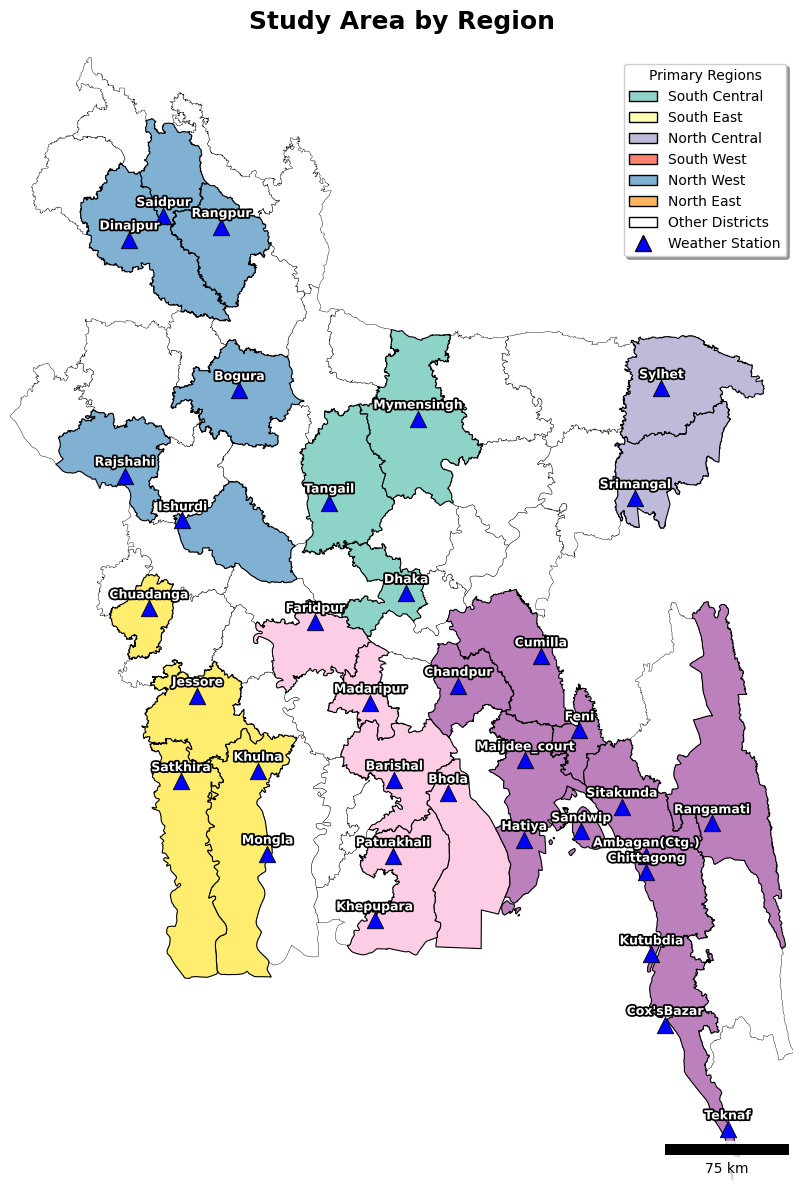

In [ ]:
import os
import glob
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.patheffects as pe
from google.colab import drive


# --- 2. INTELLIGENT SHAPE FINDER ---
search_folder = "/content/drive/MyDrive/Dry Thunderstrom"
print(f"🔍 Scanning {search_folder}...")

shapefiles = glob.glob(os.path.join(search_folder, "**", "*.shp"), recursive=True)
target_map_path = None

for file_path in shapefiles:
    filename = os.path.basename(file_path).lower()
    if 'adm2' in filename:
        try:
            test_load = gpd.read_file(file_path, rows=1)
            geom_type = test_load.geometry.iloc[0].geom_type
            if geom_type in ['Polygon', 'MultiPolygon']:
                target_map_path = file_path
                print(f"✅ Found Correct Polygon File: {filename}")
                break
        except:
            continue

if not target_map_path:
    for file_path in shapefiles:
        try:
            test_load = gpd.read_file(file_path, rows=1)
            if test_load.geometry.iloc[0].geom_type in ['Polygon', 'MultiPolygon']:
                target_map_path = file_path
                print(f"✅ Fallback using: {os.path.basename(file_path)}")
                break
        except:
            continue

if not target_map_path:
    raise FileNotFoundError("❌ No valid Map Shapefile found!")

bd_districts = gpd.read_file(target_map_path)

# --- 3. PREPARE DATA ---
try:
    cols = ['StationName', 'Latitude', 'Longitude', 'Primary_Region']
    unique_stations = df_rain[cols].drop_duplicates(subset='StationName')
except NameError:
    print("⚠️ 'df_rain' not found. Using DUMMY data.")
    import pandas as pd
    unique_stations = pd.DataFrame({
        'Station_Name': ['Dhaka', 'Chittagong', 'Sylhet', 'Rajshahi', 'Khulna'],
        'Latitude': [23.81, 22.35, 24.89, 24.36, 22.84],
        'Longitude': [90.41, 91.78, 91.86, 88.60, 89.54],
        'Primary_Region': ['Central', 'South East', 'North East', 'North West', 'South West']
    })

stations_gdf = gpd.GeoDataFrame(
    unique_stations,
    geometry=gpd.points_from_xy(unique_stations.Longitude, unique_stations.Latitude),
    crs="EPSG:4326"
)

# --- 4. COLOR LOGIC ---
bd_proj = bd_districts.to_crs(epsg=32646)
stations_proj = stations_gdf.to_crs(epsg=32646)

possible_cols = ['ADM2_EN', 'ADM2_VI', 'dist_name', 'NAME_2', 'name']
dist_col = next((c for c in possible_cols if c in bd_proj.columns), bd_proj.columns[0])

joined = gpd.sjoin(stations_proj, bd_proj, how="left", predicate="within")
district_region_map = joined.set_index(dist_col)['Primary_Region'].to_dict()
bd_proj['assigned_region'] = bd_proj[dist_col].map(district_region_map)

background_layer = bd_proj[bd_proj['assigned_region'].isna()]
study_layer = bd_proj[bd_proj['assigned_region'].notna()]

# --- 5. PLOTTING ---
fig, ax = plt.subplots(figsize=(9, 12))

# Background Colors
ax.set_facecolor('#d4f1f9')
background_layer.plot(ax=ax, color='white', edgecolor='black', linewidth=0.3)

# Study Regions
study_layer.plot(ax=ax, column='assigned_region', cmap='Set3', edgecolor='black', linewidth=0.8)

# Stations (Blue Triangles)
stations_proj.plot(ax=ax, color='blue', marker='^', markersize=140,
                   edgecolor='black', linewidth=0.6, zorder=5)

# Reduce Whitespace
minx, miny, maxx, maxy = bd_proj.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# --- 6. LABELS ---
for x, y, label in zip(stations_proj.geometry.x, stations_proj.geometry.y, stations_proj['StationName']):
    txt = ax.text(x, y + 6000, label, fontsize=9, fontweight='bold',
                  ha='center', zorder=6, color='white')
    txt.set_path_effects([pe.withStroke(linewidth=2.5, foreground='black')])

# Legend
unique_regions = study_layer['assigned_region'].unique()
cmap = plt.get_cmap('Set3')
legend_patches = []
for i, region in enumerate(unique_regions):
    color = cmap(i % 12)
    legend_patches.append(mpatches.Patch(facecolor=color, edgecolor='black', label=region))

legend_patches.append(mpatches.Patch(facecolor='white', edgecolor='black', label='Other Districts'))
legend_patches.append(plt.Line2D([0], [0], marker='^', color='w', markerfacecolor='blue',
                                 markeredgecolor='black', markersize=12, label='Weather Station'))

# --- CHANGED: Legend location moved to 'upper right' ---
ax.legend(handles=legend_patches, loc='upper right', title="Primary Regions", fontsize=10, frameon=True, shadow=True)

# Scale & Arrow
ax.add_artist(ScaleBar(1, "m", location="lower right", box_alpha=0.8))
x_arrow, y_arrow = ax.get_xlim()[1], ax.get_ylim()[1]
ax.text(x_arrow - 30000, y_arrow - 20000, 'N', fontsize=24, weight='bold', ha='center')
ax.arrow(x_arrow - 30000, y_arrow - 55000, 0, 30000, fc='k', ec='k', width=2000, head_width=7000)

ax.set_axis_off()
plt.title("Study Area by Region", fontsize=18, weight='bold', pad=20)

plt.tight_layout()
plt.savefig("Final_BlueStations_Map_Tight_LegendUR.png", dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.show()